# World Cup Match Predictor and Analyst Chatbot
## Track 1 -- GenAI Hackathon Submission

**Objective:** Build an end-to-end LangChain-powered conversational AI system that answers
natural language questions about FIFA World Cup history and generates evidence-based match
predictions using retrieval-augmented generation (RAG) and computed statistical features.

**Group 5**

**Team Members:** Novia Dsilva, Sushmitha Sudharsan, Tanmayi Shurpali


## 1. Hackathon Track Alignment

This project implements **Track 1: World Cup Match Predictor and Analyst Chatbot** and satisfies
all four required pipeline steps:

| Step | Requirement | Implementation |
|------|------------|----------------|
| 1 | Ingest CSV/JSON of historical World Cup results | Three Kaggle CSVs loaded, validated, and cleaned |
| 2 | Store in a retrievable structure (vector DB) | FAISS vector store with OpenAI embeddings |
| 3 | RAG pipeline for natural language Q&A | LangChain retrieval chain with grounded prompts |
| 4 | Prediction chain (head-to-head + recent form) | Feature-engineered prediction with LLM synthesis |

**Core requirements covered:**
- LangChain ReAct agent with 5 registered tools and custom prompt
- 6 additional pipeline functions for batch data preparation
- 4 prompt templates: RAG, prediction, fallback, and agent routing
- Conversation memory (`chat_history`) and persistent user preferences (favorite team, answer style)
- Publicly sourced Kaggle data with full reproducibility
- Grounded outputs with evidence, limitations, and assumptions


## 2. Data Sources and Reproducibility

### Primary Dataset (International Football Results)
- **Source:** [International Football Results from 1872 to 2017 on Kaggle](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)
- **Files used:**
  - `results.csv` -- 49,071 international match results (1872-2026) including all FIFA World Cups through 2022
  - `goalscorers.csv` -- 47,555 individual goal records with scorer names, minutes, and penalty/own-goal flags
  - `shootouts.csv` -- 665 penalty shootout outcomes
  - `former_names.csv` -- 36 historical team name mappings (e.g., Soviet Union -> Russia, Zaire -> DR Congo)
- **Download method:** Manual download from Kaggle, uploaded to Colab runtime
- **License:** Open data (CC BY-SA 4.0)

### Key Advantage Over Previous Datasets
This dataset covers **all international matches** (friendlies, qualifiers, tournament games), not just
World Cup matches. This enables genuinely meaningful "recent form" analysis using a team's
last N international matches regardless of competition type.

### Caching Strategy
- All raw CSVs are loaded once and processed DataFrames are cached in memory
- Cleaned datasets are saved as local CSV files in the Colab runtime
- Vector store is built once and reused across all queries


## 3. Environment Setup

In [ ]:
# Package installation for Google Colab
!pip install -q langchain==0.3.25 langchain-openai==0.3.18 langchain-community==0.3.24 faiss-cpu tiktoken openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 69.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-prebuilt 1.0.8 requires lang

In [ ]:
!pip install -q gradio

In [ ]:
# Core imports
import os
import re
import json
import warnings
import hashlib
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# LangChain imports
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import Tool
from langchain.agents import AgentExecutor, create_react_agent
from langchain.memory import ConversationBufferWindowMemory

from IPython.display import display

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (10, 5)

print("All packages imported successfully.")


All packages imported successfully.


## 4. OpenAI API Key Configuration

In [ ]:
# Load OpenAI API key from Colab Secrets
# In Google Colab, go to the key icon on the left sidebar and add your key as 'OPENAI_API_KEY'
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("OpenAI API key loaded from Colab Secrets.")
except Exception:
    # Fallback for local development -- set your key in environment variables
    if "OPENAI_API_KEY" not in os.environ:
        raise ValueError(
            "OPENAI_API_KEY not found. Add it to Colab Secrets or set it as an environment variable."
        )
    print("OpenAI API key loaded from environment.")


OpenAI API key loaded from Colab Secrets.


## 5. Data Ingestion

We load the four CSV files from the Kaggle International Football Results dataset.
Each file serves a distinct purpose in the pipeline:
- **results.csv**: Match results with scores, tournament type, location, and neutral venue flag
- **goalscorers.csv**: Individual goal records linked to matches by date and team names
- **shootouts.csv**: Penalty shootout outcomes for drawn knockout matches
- **former_names.csv**: Historical team name changes for normalization (e.g., Zaire -> DR Congo)


In [ ]:
# -------------------------------------------------------------------
# Tool 1: dataset_discovery_tool
# Discovers and catalogs available dataset files
# -------------------------------------------------------------------
def dataset_discovery_tool(data_dir: str = ".") -> str:
    """Discover available CSV files and report their basic properties."""
    expected_files = ["results.csv", "goalscorers.csv", "shootouts.csv", "former_names.csv"]
    found = []
    missing = []
    for f in expected_files:
        path = os.path.join(data_dir, f)
        if os.path.exists(path):
            size_kb = os.path.getsize(path) / 1024
            found.append({"file": f, "size_kb": round(size_kb, 1), "path": path})
        else:
            missing.append(f)
    report = {
        "found": found,
        "missing": missing,
        "status": "ready" if not missing else "incomplete"
    }
    return json.dumps(report, indent=2)


# Run discovery
print(dataset_discovery_tool("."))


{
  "found": [
    {
      "file": "results.csv",
      "size_kb": 3611.3,
      "path": "./results.csv"
    },
    {
      "file": "goalscorers.csv",
      "size_kb": 3177.2,
      "path": "./goalscorers.csv"
    },
    {
      "file": "shootouts.csv",
      "size_kb": 28.1,
      "path": "./shootouts.csv"
    },
    {
      "file": "former_names.csv",
      "size_kb": 1.7,
      "path": "./former_names.csv"
    }
  ],
  "missing": [],
  "status": "ready"
}


In [ ]:
# -------------------------------------------------------------------
# Tool 2: data_ingestion_tool
# Loads all CSV files into pandas DataFrames
# -------------------------------------------------------------------
def data_ingestion_tool(data_dir: str = ".") -> Dict[str, pd.DataFrame]:
    """Load all international football result CSV files into DataFrames."""
    results = pd.read_csv(os.path.join(data_dir, "results.csv"))
    goalscorers = pd.read_csv(os.path.join(data_dir, "goalscorers.csv"))
    shootouts = pd.read_csv(os.path.join(data_dir, "shootouts.csv"))
    former_names = pd.read_csv(os.path.join(data_dir, "former_names.csv"))
    print(f"Loaded: Results={len(results)} rows, Goalscorers={len(goalscorers)} rows, "
          f"Shootouts={len(shootouts)} rows, Former Names={len(former_names)} rows")
    return {
        "results": results,
        "goalscorers": goalscorers,
        "shootouts": shootouts,
        "former_names": former_names,
    }


raw_data = data_ingestion_tool(".")
results_raw = raw_data["results"]
goalscorers_raw = raw_data["goalscorers"]
shootouts_raw = raw_data["shootouts"]
former_names_raw = raw_data["former_names"]


Loaded: Results=49071 rows, Goalscorers=47555 rows, Shootouts=665 rows, Former Names=36 rows


In [ ]:
# Quick schema inspection
for name, df in [("Results", results_raw), ("Goalscorers", goalscorers_raw),
                 ("Shootouts", shootouts_raw), ("Former Names", former_names_raw)]:
    print(f"\n{'='*60}")
    print(f"  {name} -- Shape: {df.shape}")
    print(f"{'='*60}")
    print(df.dtypes)
    print(f"\nFirst 2 rows:")
    display(df.head(2))



  Results -- Shape: (49071, 9)
date          object
home_team     object
away_team     object
home_score     int64
away_score     int64
tournament    object
city          object
country       object
neutral         bool
dtype: object

First 2 rows:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False



  Goalscorers -- Shape: (47555, 8)
date          object
home_team     object
away_team     object
team          object
scorer        object
minute       float64
own_goal        bool
penalty         bool
dtype: object

First 2 rows:


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False



  Shootouts -- Shape: (665, 5)
date             object
home_team        object
away_team        object
winner           object
first_shooter    object
dtype: object

First 2 rows:


,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN



  Former Names -- Shape: (36, 4)
current       object
former        object
start_date    object
end_date      object
dtype: object

First 2 rows:


,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04


## 6. Data Validation

We perform thorough validation before any analysis:
- Schema and type checks for all datasets
- Missing value analysis with per-column counts and percentages
- Duplicate detection (exact row matches)
- Sanity checks for impossible values (negative scores)
- Date range and tournament coverage verification

**Note:** This dataset is exceptionally clean -- zero nulls and zero duplicates in
the primary results file. Validation confirms this and checks for edge cases.


In [ ]:
# -------------------------------------------------------------------
# Tool 3: data_validation_tool
# Validates data quality and reports issues
# -------------------------------------------------------------------
def data_validation_tool(results: pd.DataFrame, goalscorers: pd.DataFrame,
                         shootouts: pd.DataFrame) -> str:
    """Run comprehensive validation checks on all datasets."""
    report = []

    # --- Results validation ---
    report.append("=== RESULTS VALIDATION ===")
    report.append(f"Shape: {results.shape}")

    missing = results.isnull().sum()
    has_missing = missing[missing > 0]
    if len(has_missing) > 0:
        report.append("Columns with missing values:")
        for col in has_missing.index:
            pct = round(has_missing[col] / len(results) * 100, 2)
            report.append(f"  {col}: {has_missing[col]} ({pct}%)")
    else:
        report.append("No missing values found.")

    dup_count = results.duplicated().sum()
    report.append(f"Duplicate rows: {dup_count}")

    neg_home = (results["home_score"] < 0).sum()
    neg_away = (results["away_score"] < 0).sum()
    report.append(f"Negative home scores: {neg_home}, Negative away scores: {neg_away}")
    report.append(f"Date range: {results['date'].min()} to {results['date'].max()}")
    report.append(f"Unique tournaments: {results['tournament'].nunique()}")

    wc_count = len(results[results["tournament"] == "FIFA World Cup"])
    report.append(f"FIFA World Cup matches: {wc_count}")

    # --- Goalscorers validation ---
    report.append("\n=== GOALSCORERS VALIDATION ===")
    report.append(f"Shape: {goalscorers.shape}")
    gs_missing = goalscorers.isnull().sum()
    gs_has_missing = gs_missing[gs_missing > 0]
    if len(gs_has_missing) > 0:
        for col in gs_has_missing.index:
            report.append(f"  {col}: {gs_has_missing[col]} missing")
    report.append(f"Unique scorers: {goalscorers['scorer'].nunique()}")

    # --- Shootouts validation ---
    report.append("\n=== SHOOTOUTS VALIDATION ===")
    report.append(f"Shape: {shootouts.shape}")
    report.append(f"Date range: {shootouts['date'].min()} to {shootouts['date'].max()}")

    return "\n".join(report)


print(data_validation_tool(results_raw, goalscorers_raw, shootouts_raw))


=== RESULTS VALIDATION ===
Shape: (49071, 9)
No missing values found.
Duplicate rows: 0
Negative home scores: 0, Negative away scores: 0
Date range: 1872-11-30 to 2026-01-26
Unique tournaments: 191
FIFA World Cup matches: 964

=== GOALSCORERS VALIDATION ===
Shape: (47555, 8)
  scorer: 48 missing
  minute: 256 missing
Unique scorers: 15322

=== SHOOTOUTS VALIDATION ===
Shape: (665, 5)
Date range: 1967-08-22 to 2026-01-17


## 7. Data Preprocessing

Key cleaning steps applied to the datasets:

**Results (results.csv):**
1. **Parse dates** -- convert string dates to proper datetime objects
2. **Extract Year** -- derive tournament year for grouping and filtering
3. **Apply former_names.csv** -- normalize historical team names (e.g., Soviet Union -> Russia)
4. **Derive Result column** -- classify each match as Home Win, Away Win, or Draw
5. **Derive TotalGoals column** -- sum of home and away scores
6. **Filter World Cup subset** -- create a dedicated WC-only DataFrame for tournament-specific analysis

**Goalscorers (goalscorers.csv):**
- Strip whitespace from scorer names
- Parse minute values as numeric
- Apply same team name normalization


In [ ]:
# -------------------------------------------------------------------
# Tool 4: preprocessing_tool
# Cleans and transforms raw data into analysis-ready DataFrames
# -------------------------------------------------------------------

def build_name_map(former_names_df: pd.DataFrame) -> Dict[str, str]:
    """Build a team name normalization map from former_names.csv."""
    name_map = {}
    for _, row in former_names_df.iterrows():
        name_map[row["former"]] = row["current"]
    return name_map


def normalize_team_name(name, name_map):
    """Normalize a team name using the former_names mapping."""
    if pd.isna(name):
        return name
    name = str(name).strip()
    return name_map.get(name, name)


def preprocessing_tool(results: pd.DataFrame, former_names: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Clean and preprocess the results DataFrame. Returns (all_matches, wc_matches)."""
    df = results.copy()
    print(f"Starting rows: {len(df)}")

    # 1. Parse dates
    df["ParsedDate"] = pd.to_datetime(df["date"], errors="coerce")
    valid_dates = df["ParsedDate"].notna().sum()
    print(f"Parsed {valid_dates}/{len(df)} dates successfully")

    # 2. Extract Year
    df["Year"] = df["ParsedDate"].dt.year

    # 3. Build name map from former_names.csv and normalize team names
    name_map = build_name_map(former_names)
    print(f"Loaded {len(name_map)} historical team name mappings")
    df["home_team"] = df["home_team"].apply(lambda x: normalize_team_name(x, name_map))
    df["away_team"] = df["away_team"].apply(lambda x: normalize_team_name(x, name_map))

    remapped = sum(1 for t in results["home_team"].unique() if t in name_map)
    remapped += sum(1 for t in results["away_team"].unique() if t in name_map)
    print(f"Team names remapped: {remapped} unique names normalized via former_names.csv")

    # 4. Remove any duplicates
    before = len(df)
    df = df.drop_duplicates()
    print(f"Duplicates removed: {before - len(df)}")

    # 5. Derive match result
    def get_result(row):
        if row["home_score"] > row["away_score"]:
            return "Home Win"
        elif row["home_score"] < row["away_score"]:
            return "Away Win"
        return "Draw"

    df["Result"] = df.apply(get_result, axis=1)

    # 6. Total goals
    df["TotalGoals"] = df["home_score"] + df["away_score"]

    # 7. Filter World Cup matches
    wc = df[df["tournament"] == "FIFA World Cup"].copy()
    print(f"\nAll matches: {len(df)} rows")
    print(f"World Cup matches: {len(wc)} rows")
    print(f"WC tournaments covered: {sorted(wc['Year'].dropna().unique().astype(int))}")
    print(f"Unique teams (all): {len(set(df['home_team']) | set(df['away_team']))}")
    print(f"Unique teams (WC): {len(set(wc['home_team']) | set(wc['away_team']))}")

    return df, wc


matches_all, matches_wc = preprocessing_tool(results_raw, former_names_raw)
matches_clean = matches_wc


Starting rows: 49071
Parsed 49071/49071 dates successfully
Loaded 36 historical team name mappings
Team names remapped: 0 unique names normalized via former_names.csv
Duplicates removed: 0

All matches: 49071 rows
World Cup matches: 964 rows
WC tournaments covered: [np.int64(1930), np.int64(1934), np.int64(1938), np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
Unique teams (all): 333
Unique teams (WC): 82


In [ ]:
# -------------------------------------------------------------------
# Preprocess the Goalscorers dataset
# -------------------------------------------------------------------

def preprocess_goalscorers(goalscorers: pd.DataFrame, name_map: Dict[str, str]) -> pd.DataFrame:
    """Clean and preprocess the goalscorers dataset."""
    df = goalscorers.copy()
    print(f"Goalscorers starting rows: {len(df)}")

    before = len(df)
    df = df.drop_duplicates()
    print(f"Removed {before - len(df)} duplicate rows, {len(df)} remain")

    df["scorer"] = df["scorer"].astype(str).str.strip()
    df["team"] = df["team"].apply(lambda x: normalize_team_name(x, name_map))
    df["home_team"] = df["home_team"].apply(lambda x: normalize_team_name(x, name_map))
    df["away_team"] = df["away_team"].apply(lambda x: normalize_team_name(x, name_map))

    df["minute"] = pd.to_numeric(df["minute"], errors="coerce")
    df["ParsedDate"] = pd.to_datetime(df["date"], errors="coerce")

    print(f"Unique scorers: {df['scorer'].nunique()}")
    print(f"Penalty goals: {df['penalty'].sum()}")
    print(f"Own goals: {df['own_goal'].sum()}")
    print(f"Final shape: {df.shape}")

    return df


name_map = build_name_map(former_names_raw)
goalscorers_clean = preprocess_goalscorers(goalscorers_raw, name_map)


Goalscorers starting rows: 47555
Removed 82 duplicate rows, 47473 remain
Unique scorers: 15323
Penalty goals: 3245
Own goals: 921
Final shape: (47473, 9)


In [ ]:
# Cache cleaned data
matches_all.to_csv("matches_all_cleaned.csv", index=False)
matches_wc.to_csv("matches_wc_cleaned.csv", index=False)
goalscorers_clean.to_csv("goalscorers_cleaned.csv", index=False)
print("Cleaned datasets cached to local CSV files.")

print(f"\nAll matches  -- final shape: {matches_all.shape}")
print(f"WC matches   -- final shape: {matches_wc.shape}")
print(f"Goalscorers  -- final shape: {goalscorers_clean.shape}")

print(f"\nAll matches columns: {list(matches_all.columns)}")
display(matches_wc.head(3))


Cleaned datasets cached to local CSV files.

All matches  -- final shape: (49071, 13)
WC matches   -- final shape: (964, 13)
Goalscorers  -- final shape: (47473, 9)

All matches columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'ParsedDate', 'Year', 'Result', 'TotalGoals']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,ParsedDate,Year,Result,TotalGoals
1486,1930-07-13,Belgium,United States,0,3,FIFA World Cup,Montevideo,Uruguay,True,1930-07-13,1930,Away Win,3
1487,1930-07-13,France,Mexico,4,1,FIFA World Cup,Montevideo,Uruguay,True,1930-07-13,1930,Home Win,5
1488,1930-07-14,Brazil,Yugoslavia,1,2,FIFA World Cup,Montevideo,Uruguay,True,1930-07-14,1930,Away Win,3


## 8. Exploratory Data Analysis and Visualizations

This section provides rich visual analysis to understand the dataset and support the
prediction pipeline. Each chart includes a brief interpretation.


In [ ]:
# -------------------------------------------------------------------
# EDA styling configuration
# -------------------------------------------------------------------

# Consistent color palette across all charts
PALETTE = {
    "primary": "#1B4F72",
    "secondary": "#A23B72",
    "accent": "#E67E22",
    "positive": "#27AE60",
    "neutral": "#7F8C8D",
    "negative": "#C0392B",
    "gradient": plt.cm.YlOrRd,
    "team_a": "#009B3A",
    "team_b": "#1A1A2E",
    "draw": "#BDC3C7",
}

CHART_STYLE = {
    "title_size": 14,
    "label_size": 12,
    "tick_size": 10,
    "annotation_size": 11,
    "figsize_wide": (13, 5),
    "figsize_square": (8, 7),
    "figsize_h2h": (8, 5),
}


def style_ax(ax, title, xlabel="", ylabel="", grid_axis="y"):
    """Apply consistent styling to an axis."""
    ax.set_title(title, fontsize=CHART_STYLE["title_size"], fontweight="bold", pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=CHART_STYLE["label_size"])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=CHART_STYLE["label_size"])
    ax.tick_params(axis="both", labelsize=CHART_STYLE["tick_size"])
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def annotate_bars(ax, bars, fmt="{:.0f}", fontsize=None, offset=0.3):
    """Add value labels to bar charts."""
    fs = fontsize or CHART_STYLE["annotation_size"]
    for bar in bars:
        val = bar.get_height() if bar.get_height() > 0 else bar.get_width()
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                    fmt.format(val), ha="center", va="bottom", fontsize=fs, fontweight="bold")
        else:
            ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
                    fmt.format(val), ha="left", va="center", fontsize=fs, fontweight="bold")


def annotate_hbars(ax, bars, fmt="{:.0f}", fontsize=None, offset=0.1):
    """Add value labels to horizontal bar charts."""
    fs = fontsize or CHART_STYLE["annotation_size"]
    for bar in bars:
        val = bar.get_width()
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                fmt.format(val), ha="left", va="center", fontsize=fs, fontweight="bold")


print("EDA style configuration loaded.")

EDA style configuration loaded.


In [ ]:
# -------------------------------------------------------------------
# Tool 5: eda_visualization_tool
# -------------------------------------------------------------------

def eda_visualization_tool(wc_matches: pd.DataFrame, all_matches: pd.DataFrame) -> None:
    """Generate all EDA visualizations with polished styling."""

    fig_num = 0

    # ================================================================
    # Chart 1: Matches per WC Tournament Year
    # ================================================================
    fig_num += 1
    fig, ax = plt.subplots(figsize=CHART_STYLE["figsize_wide"])
    match_counts = wc_matches.groupby("Year").size()
    bars = ax.bar(match_counts.index.astype(int).astype(str), match_counts.values,
                  color=PALETTE["primary"], edgecolor="white", linewidth=0.5)
    style_ax(ax, f"Fig {fig_num}: Number of Matches per World Cup Tournament", "Tournament Year", "Matches")
    annotate_bars(ax, bars, fontsize=9, offset=0.2)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print(">> Match count has grown as the tournament expanded from 13 teams (1930) to 32 teams (1998-2022).\n")

    # ================================================================
    # Chart 2: Total Goals per WC Tournament
    # ================================================================
    fig_num += 1
    fig, ax = plt.subplots(figsize=CHART_STYLE["figsize_wide"])
    goals_per_year = wc_matches.groupby("Year")["TotalGoals"].sum()
    ax.plot(goals_per_year.index, goals_per_year.values, marker="o", color=PALETTE["secondary"],
            linewidth=2.5, markersize=6, zorder=3)
    ax.fill_between(goals_per_year.index, goals_per_year.values, alpha=0.1, color=PALETTE["secondary"])
    for x, y in zip(goals_per_year.index, goals_per_year.values):
        if y == goals_per_year.max() or y == goals_per_year.min():
            ax.annotate(f"{int(y)}", (x, y), textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=9, fontweight="bold", color=PALETTE["secondary"])
    style_ax(ax, f"Fig {fig_num}: Total Goals Scored per World Cup Tournament", "Year", "Total Goals")
    plt.tight_layout()
    plt.show()
    print(">> Goal totals have increased with more matches per tournament. Peak and trough years are annotated.\n")

    # ================================================================
    # Chart 3: Average Goals per WC Match
    # ================================================================
    fig_num += 1
    fig, ax = plt.subplots(figsize=CHART_STYLE["figsize_wide"])
    avg_goals = wc_matches.groupby("Year")["TotalGoals"].mean()
    overall_avg = avg_goals.mean()
    bar_colors = [PALETTE["accent"] if v >= overall_avg else PALETTE["neutral"] for v in avg_goals.values]
    bars = ax.bar(avg_goals.index.astype(int).astype(str), avg_goals.values,
                  color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.axhline(y=overall_avg, color=PALETTE["negative"], linestyle="--", linewidth=1.5,
               label=f"Overall average: {overall_avg:.2f}")
    style_ax(ax, f"Fig {fig_num}: Average Goals per Match by Tournament", "Tournament Year", "Avg Goals per Match")
    ax.legend(fontsize=CHART_STYLE["tick_size"], loc="upper right")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print(">> Tournaments above average are highlighted. Early era football was more attacking.\n")

    # ================================================================
    # Chart 4: World Cup Title Winners
    # ================================================================
    fig_num += 1
    fig, ax = plt.subplots(figsize=CHART_STYLE["figsize_h2h"])
    wc_sorted = wc_matches.sort_values("ParsedDate")
    last_per_year = wc_sorted.groupby("Year").last().reset_index()
    winners = []
    for _, row in last_per_year.iterrows():
        if row["home_score"] > row["away_score"]:
            winners.append(row["home_team"])
        elif row["away_score"] > row["home_score"]:
            winners.append(row["away_team"])
        else:
            winners.append(row["home_team"])
    winner_counts = pd.Series(winners).value_counts().head(10)

    cmap = plt.cm.Blues(np.linspace(0.3, 0.85, len(winner_counts)))
    bars = ax.barh(winner_counts.index[::-1], winner_counts.values[::-1], color=cmap[::-1], edgecolor="white")
    annotate_hbars(ax, bars)
    style_ax(ax, f"Fig {fig_num}: Teams with Most World Cup Titles (Derived)", xlabel="Number of Titles",
             grid_axis="x")
    plt.tight_layout()
    plt.show()
    print(">> Brazil leads with 5 titles. Titles derived from final match results in each tournament year.\n")

    # ================================================================
    # Chart 5: Top 15 Teams by WC Match Wins
    # ================================================================
    fig_num += 1
    home_wins = wc_matches[wc_matches["Result"] == "Home Win"]["home_team"].value_counts()
    away_wins = wc_matches[wc_matches["Result"] == "Away Win"]["away_team"].value_counts()
    total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(12, 7))
    cmap = plt.cm.viridis(np.linspace(0.3, 0.9, len(total_wins)))
    bars = ax.barh(total_wins.index[::-1], total_wins.values[::-1], color=cmap[::-1], edgecolor="white")
    annotate_hbars(ax, bars)
    style_ax(ax, f"Fig {fig_num}: Top 15 Teams by Total World Cup Match Wins", xlabel="Total Wins", grid_axis="x")
    plt.tight_layout()
    plt.show()
    print(">> Brazil and Germany lead in total World Cup match victories.\n")

    # ================================================================
    # Chart 6: WC Outcome Distribution
    # ================================================================
    fig_num += 1
    result_counts = wc_matches["Result"].value_counts()
    fig, ax = plt.subplots(figsize=(7, 7))
    wedges, texts, autotexts = ax.pie(
        result_counts.values, labels=result_counts.index, autopct="%1.1f%%",
        colors=[PALETTE["primary"], PALETTE["accent"], PALETTE["secondary"]],
        startangle=90, textprops={"fontsize": 12},
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        pctdistance=0.75
    )
    for t in autotexts:
        t.set_fontweight("bold")
        t.set_color("white")
    centre_circle = plt.Circle((0, 0), 0.50, fc="white")
    ax.add_artist(centre_circle)
    ax.set_title(f"Fig {fig_num}: World Cup Match Outcome Distribution",
                 fontsize=CHART_STYLE["title_size"], fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()
    print(">> Displayed as a donut chart. Home wins are the most common World Cup outcome.\n")

    # ================================================================
    # Chart 7: International Matches per Decade
    # ================================================================
    fig_num += 1
    fig, ax = plt.subplots(figsize=CHART_STYLE["figsize_wide"])
    ac = all_matches.copy()
    ac["Decade"] = (ac["Year"] // 10 * 10).astype(int)
    decade_counts = ac.groupby("Decade").size()
    bars = ax.bar(decade_counts.index.astype(str), decade_counts.values,
                  color=PALETTE["primary"], edgecolor="white", linewidth=0.5)
    annotate_bars(ax, bars, fontsize=9, offset=20)
    style_ax(ax, f"Fig {fig_num}: International Matches per Decade (All Competitions)", "Decade", "Total Matches")
    plt.tight_layout()
    plt.show()
    print(">> International football has grown exponentially since the 1950s.\n")

    # ================================================================
    # Chart 8: Head-to-Head -- Brazil vs Germany (All Competitions)
    # ================================================================
    fig_num += 1
    team_a, team_b = "Brazil", "Germany"
    h2h = all_matches[
        ((all_matches["home_team"] == team_a) & (all_matches["away_team"] == team_b)) |
        ((all_matches["home_team"] == team_b) & (all_matches["away_team"] == team_a))
    ]
    if len(h2h) > 0:
        a_w, b_w, dr = 0, 0, 0
        for _, row in h2h.iterrows():
            if row["home_score"] > row["away_score"]:
                w = row["home_team"]
            elif row["away_score"] > row["home_score"]:
                w = row["away_team"]
            else:
                dr += 1
                continue
            if w == team_a:
                a_w += 1
            else:
                b_w += 1

        fig, ax = plt.subplots(figsize=CHART_STYLE["figsize_h2h"])
        cats = [f"{team_a}\nWins", "Draws", f"{team_b}\nWins"]
        vals = [a_w, dr, b_w]
        bars = ax.bar(cats, vals, color=[PALETTE["team_a"], PALETTE["draw"], PALETTE["team_b"]],
                      edgecolor="white", width=0.5, linewidth=1.5)
        annotate_bars(ax, bars, fontsize=14, offset=0.15)
        style_ax(ax, f"Fig {fig_num}: {team_a} vs {team_b} -- All International Matches ({len(h2h)} total)",
                 ylabel="Matches", grid_axis="y")
        plt.tight_layout()
        plt.show()
        print(f">> {team_a} and {team_b} have met {len(h2h)} times across all competitions.\n")

    # ================================================================
    # Chart 9: WC Meeting Frequency Heatmap -- Top 8 Teams
    # ================================================================
    fig_num += 1
    top_teams = ["Brazil", "Germany", "Argentina", "Italy", "France", "Spain", "England", "Netherlands"]
    meeting_matrix = pd.DataFrame(0, index=top_teams, columns=top_teams)
    for _, row in wc_matches.iterrows():
        h, a = row["home_team"], row["away_team"]
        if h in top_teams and a in top_teams:
            meeting_matrix.loc[h, a] += 1
            meeting_matrix.loc[a, h] += 1

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(meeting_matrix.values, cmap="YlOrRd", aspect="auto", vmin=0)
    ax.set_xticks(range(len(top_teams)))
    ax.set_yticks(range(len(top_teams)))
    ax.set_xticklabels(top_teams, rotation=45, ha="right", fontsize=CHART_STYLE["tick_size"])
    ax.set_yticklabels(top_teams, fontsize=CHART_STYLE["tick_size"])

    for i in range(len(top_teams)):
        for j in range(len(top_teams)):
            val = int(meeting_matrix.values[i, j])
            if val > 0:
                text_color = "white" if val > meeting_matrix.values.max() * 0.6 else "black"
                ax.text(j, i, str(val), ha="center", va="center",
                        fontsize=CHART_STYLE["annotation_size"], fontweight="bold", color=text_color)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8, label="Number of WC Meetings")
    cbar.ax.tick_params(labelsize=CHART_STYLE["tick_size"])
    ax.set_title(f"Fig {fig_num}: World Cup Meeting Frequency -- Top 8 Teams",
                 fontsize=CHART_STYLE["title_size"], fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()
    print(">> The heatmap reveals which elite teams have faced each other most often in World Cup history.\n")

    print(f"\nEDA complete: {fig_num} visualizations generated.")


    # Chart 12: Number of Teams per World Cup
    fig_num += 1
    fig, ax = plt.subplots(figsize=CHART_STYLE["figsize_wide"])
    teams_per_wc = wc_matches.groupby("Year").apply(
        lambda x: len(set(x["home_team"]) | set(x["away_team"]))
    )
    bars = ax.bar(teams_per_wc.index.astype(int).astype(str), teams_per_wc.values,
                  color=PALETTE["primary"], edgecolor="white", linewidth=0.5)
    annotate_bars(ax, bars, fontsize=9, offset=0.2)
    style_ax(ax, f"Fig {fig_num}: Number of Participating Teams per World Cup", "Year", "Teams")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print(">> The World Cup expanded from 13 teams (1930) to 32 teams (1998 onward). 2026 will have 48.\n")

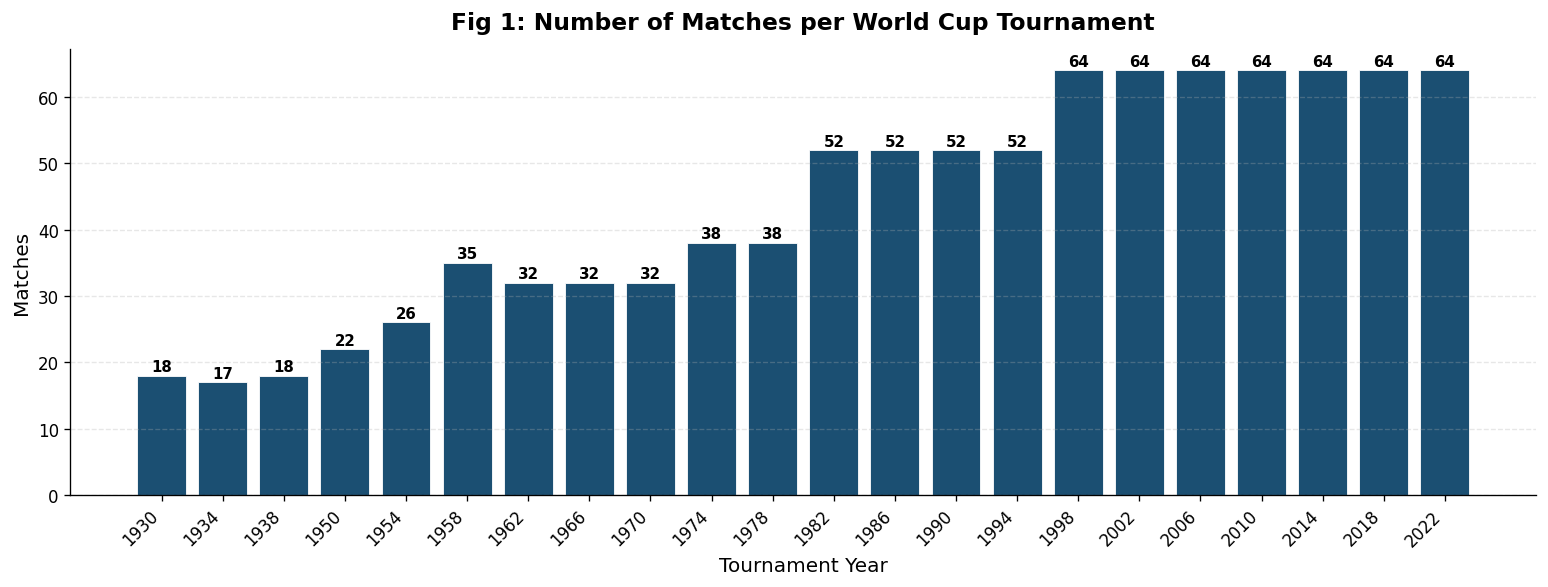

>> Match count has grown as the tournament expanded from 13 teams (1930) to 32 teams (1998-2022).



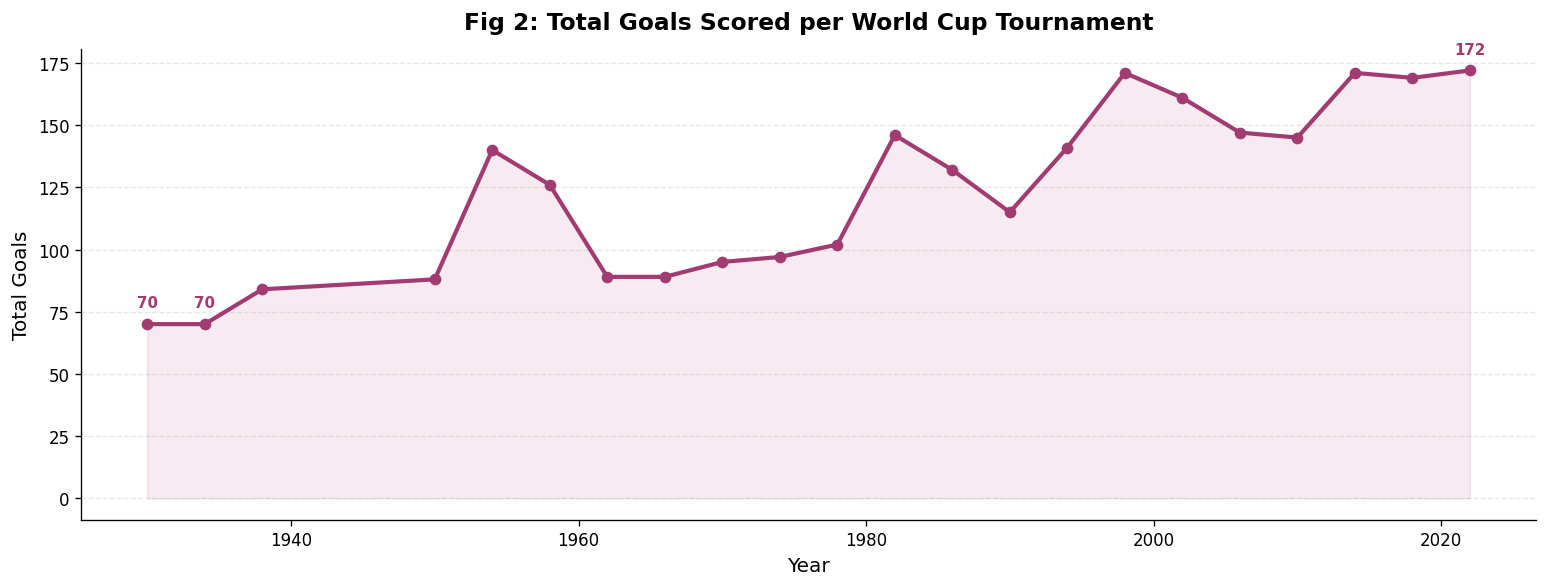

>> Goal totals have increased with more matches per tournament. Peak and trough years are annotated.



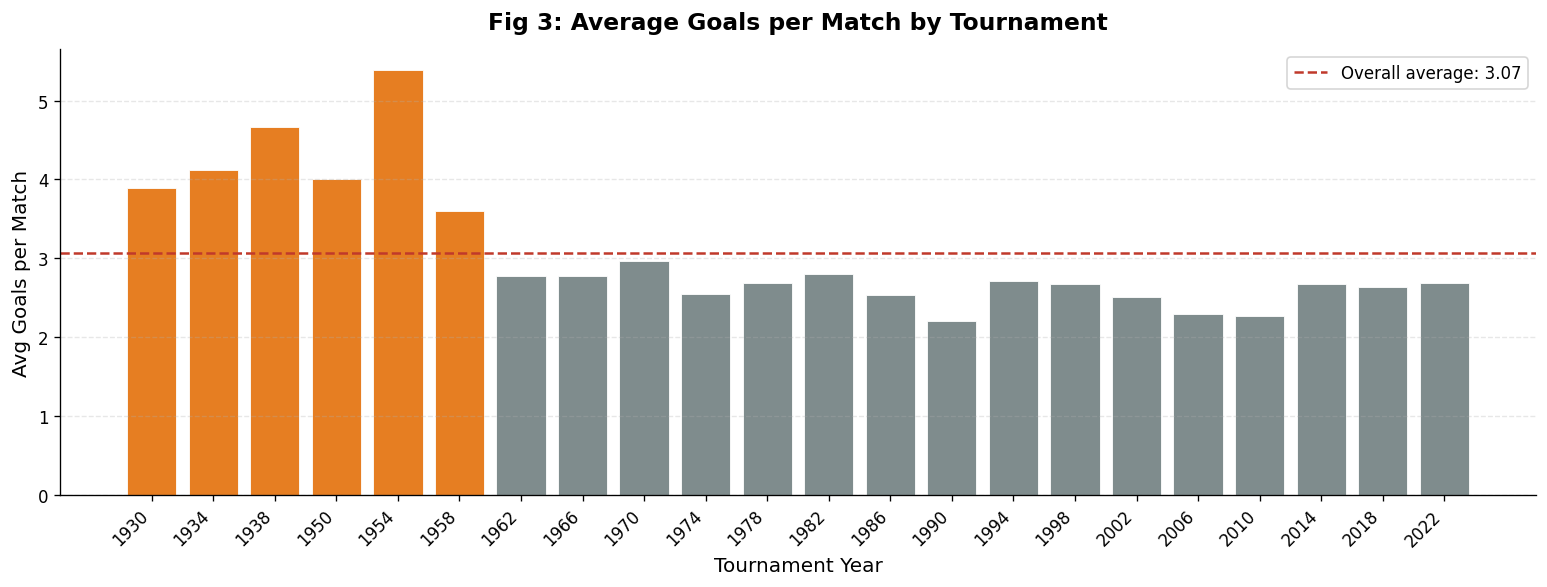

>> Tournaments above average are highlighted. Early era football was more attacking.



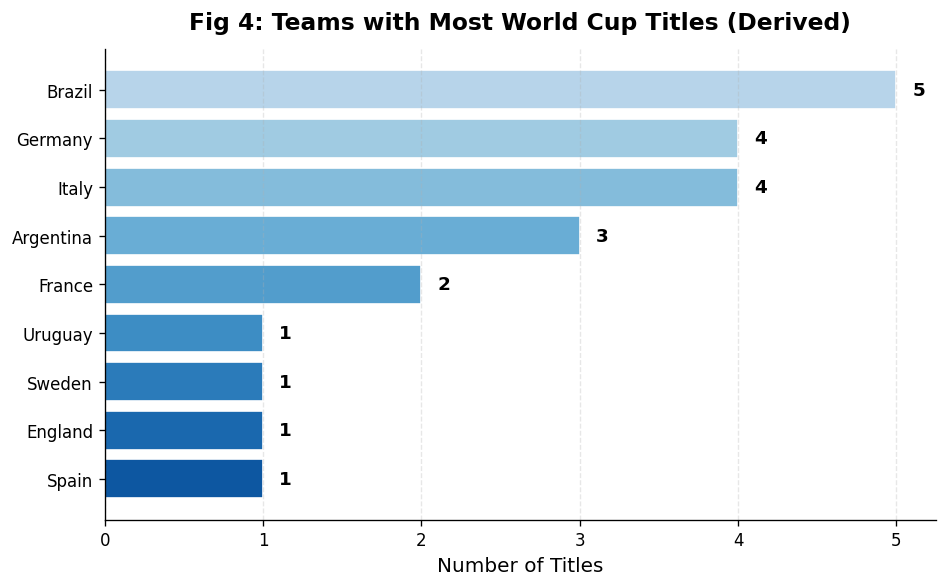

>> Brazil leads with 5 titles. Titles derived from final match results in each tournament year.



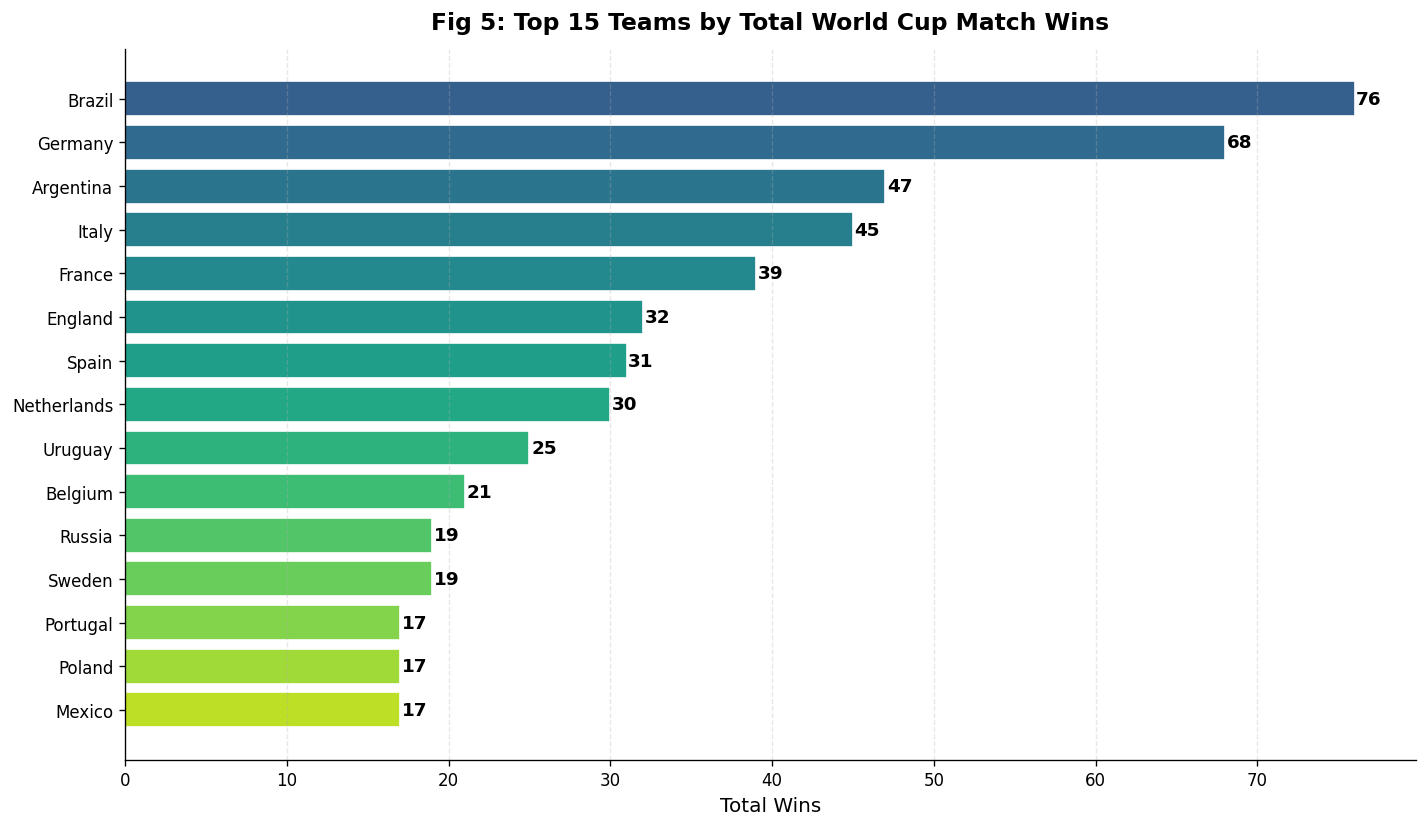

>> Brazil and Germany lead in total World Cup match victories.



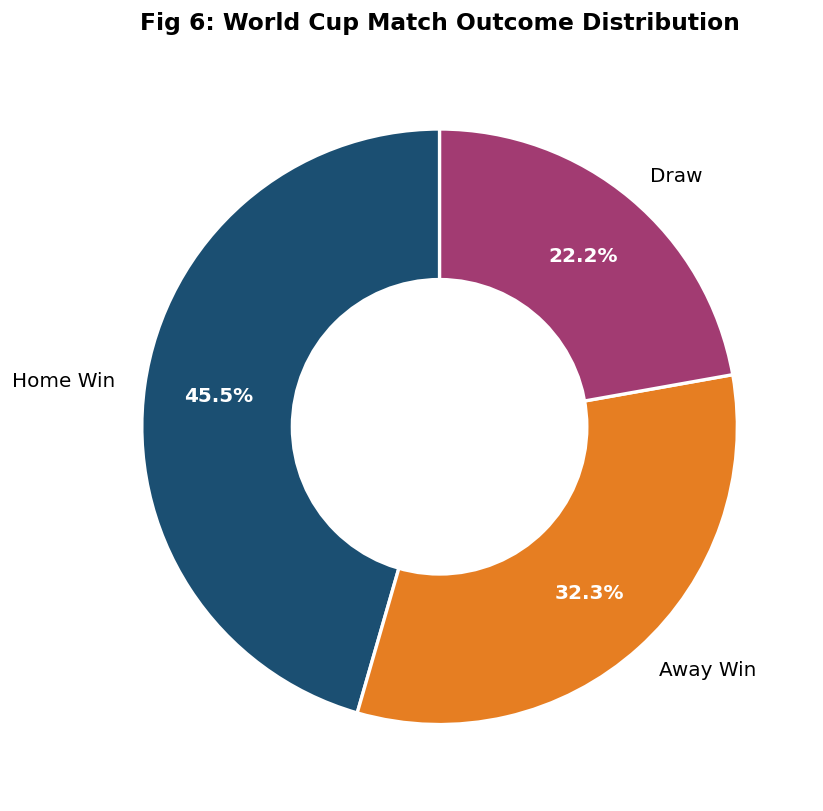

>> Displayed as a donut chart. Home wins are the most common World Cup outcome.



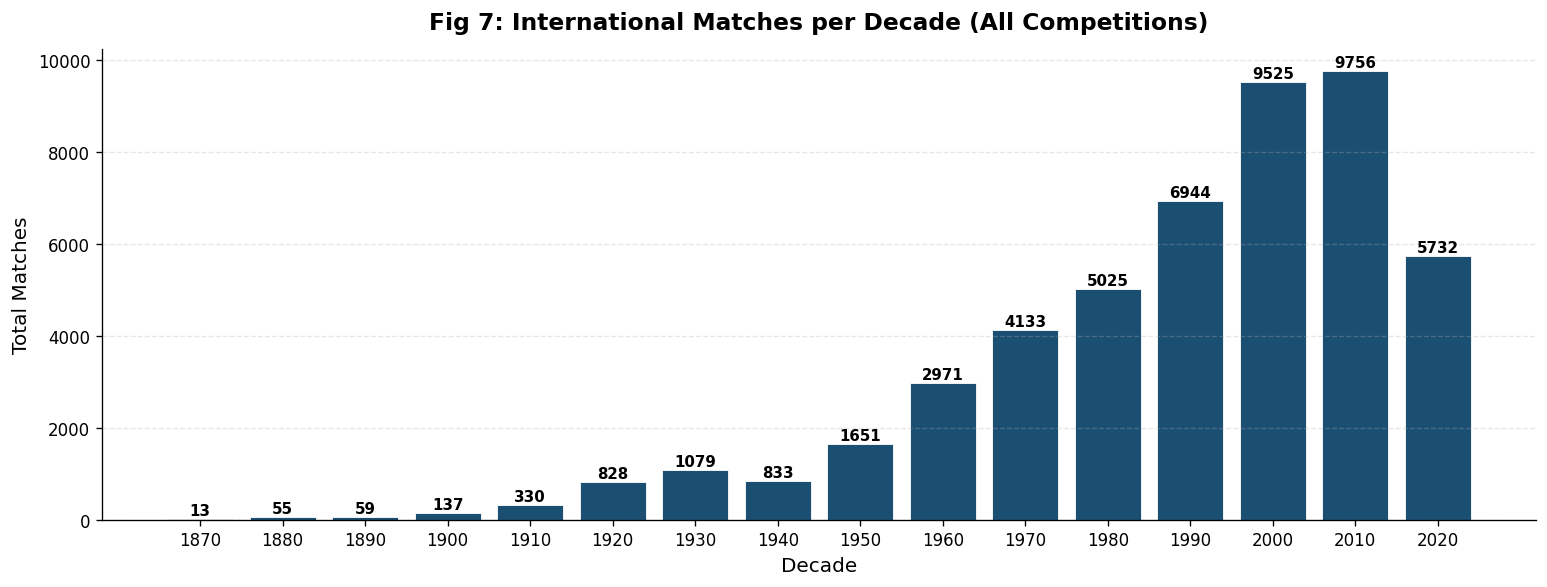

>> International football has grown exponentially since the 1950s.



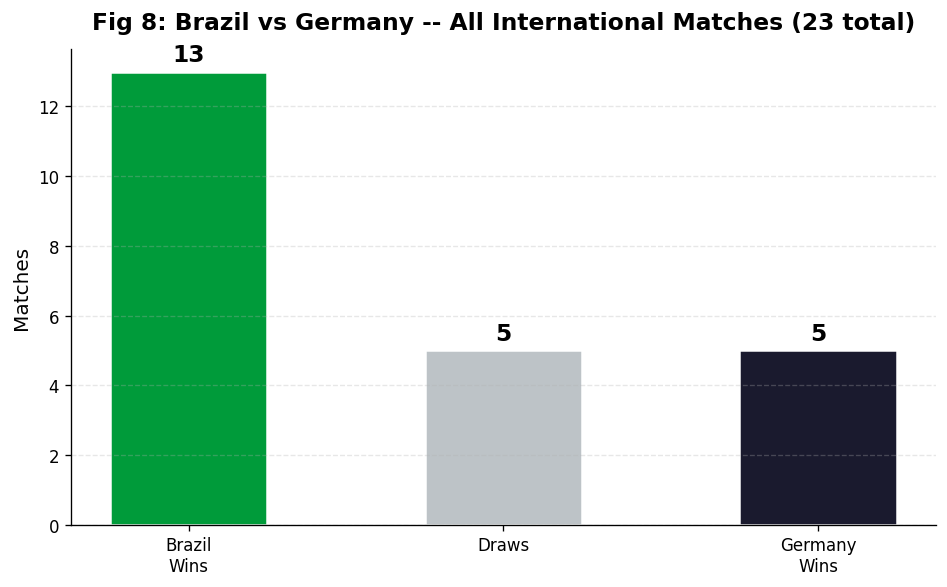

>> Brazil and Germany have met 23 times across all competitions.



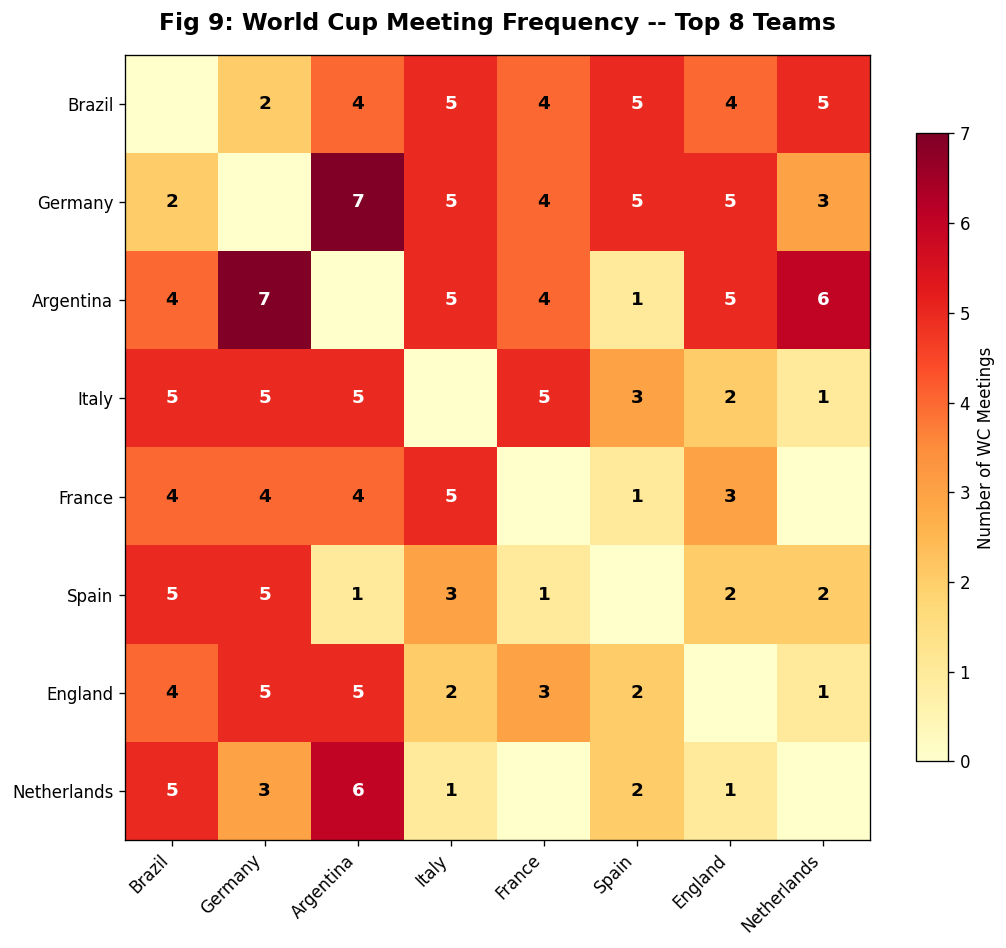

>> The heatmap reveals which elite teams have faced each other most often in World Cup history.


EDA complete: 9 visualizations generated.


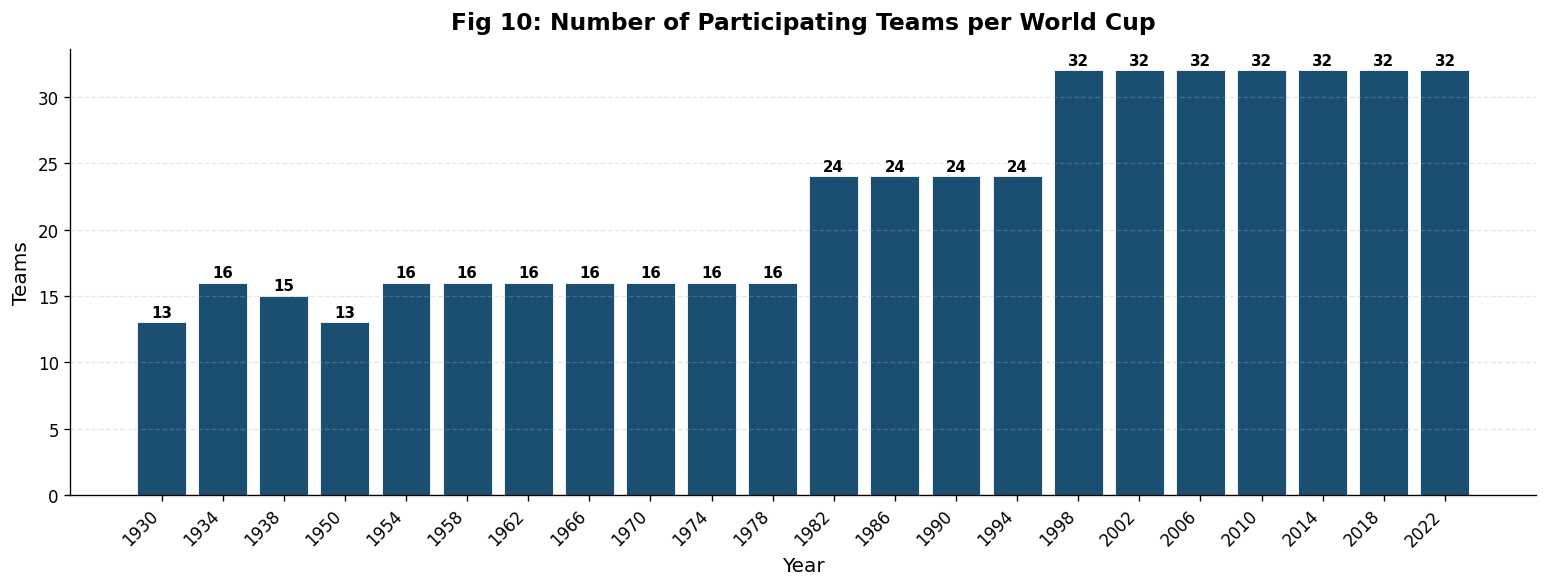

>> The World Cup expanded from 13 teams (1930) to 32 teams (1998 onward). 2026 will have 48.



In [ ]:
eda_visualization_tool(matches_wc, matches_all)

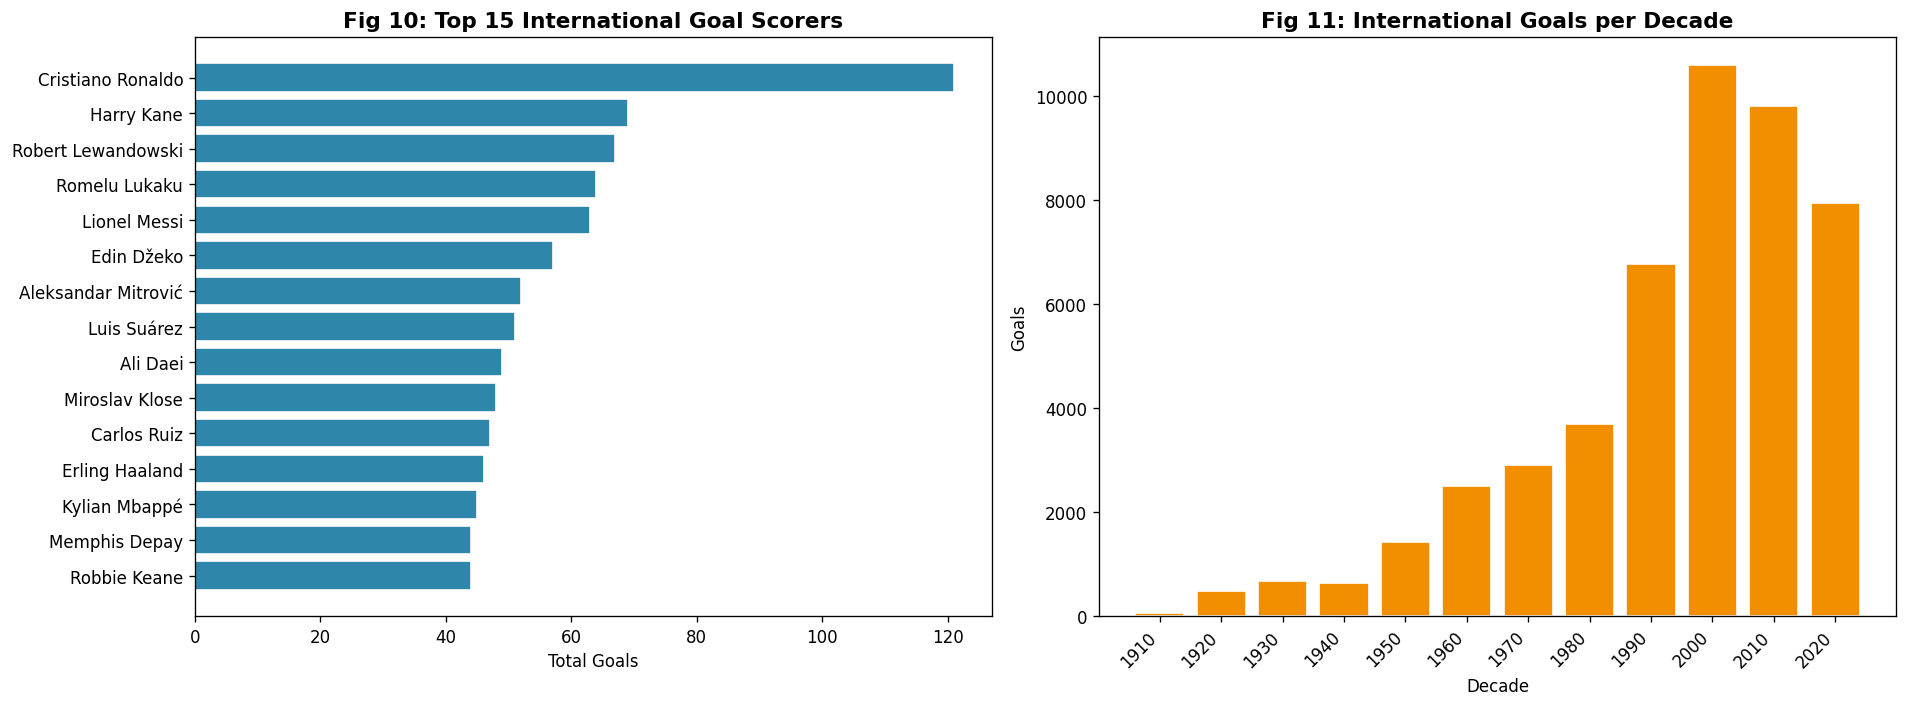

>> Goalscoring has increased with the growth of international football.



In [ ]:
# -------------------------------------------------------------------
# Additional EDA: Goalscorer analysis
# -------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 10: Top 15 International Goal Scorers
ax = axes[0]
top_scorers = (
    goalscorers_clean[goalscorers_clean["scorer"] != "nan"]
    .groupby("scorer").size()
    .sort_values(ascending=False).head(15)
)
ax.barh(top_scorers.index[::-1], top_scorers.values[::-1], color="#2E86AB", edgecolor="white")
ax.set_title("Fig 10: Top 15 International Goal Scorers", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Goals")

# Chart 11: Goals per Decade
ax = axes[1]
gs_copy = goalscorers_clean.copy()
gs_copy["Year"] = gs_copy["ParsedDate"].dt.year
gs_copy["Decade"] = (gs_copy["Year"] // 10 * 10).astype(int)
goals_decade = gs_copy.groupby("Decade").size()
ax.bar(goals_decade.index.astype(str), goals_decade.values, color="#F18F01", edgecolor="white")
ax.set_title("Fig 11: International Goals per Decade", fontsize=13, fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Goals")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()
print(">> Goalscoring has increased with the growth of international football.\n")


## 9. Document Preparation for RAG

We transform structured data into natural language documents suitable for embedding
and retrieval. Each document represents a semantically meaningful chunk of World Cup knowledge.


In [ ]:
# -------------------------------------------------------------------
# Build RAG documents from structured data
# -------------------------------------------------------------------

def build_rag_documents(wc_matches: pd.DataFrame, all_matches: pd.DataFrame) -> List[Document]:
    """Convert structured match data into LangChain Document objects for RAG."""
    docs = []

    # --- Tournament summary documents ---
    for year in sorted(wc_matches["Year"].dropna().unique()):
        year = int(year)
        yr = wc_matches[wc_matches["Year"] == year]
        total_goals = int(yr["TotalGoals"].sum())
        num_matches = len(yr)
        teams = sorted(set(yr["home_team"]) | set(yr["away_team"]))
        host = yr["country"].mode().iloc[0] if len(yr) > 0 else "Unknown"

        last = yr.sort_values("ParsedDate").iloc[-1]
        if last["home_score"] > last["away_score"]:
            winner, runner_up = last["home_team"], last["away_team"]
        elif last["away_score"] > last["home_score"]:
            winner, runner_up = last["away_team"], last["home_team"]
        else:
            winner, runner_up = last["home_team"], last["away_team"]

        text = (
            f"The {year} FIFA World Cup was held in {host}. "
            f"The winner was {winner}, defeating {runner_up} in the final. "
            f"A total of {total_goals} goals were scored in {num_matches} matches. "
            f"{len(teams)} teams participated."
        )
        docs.append(Document(page_content=text,
            metadata={"source": "tournament_summary", "year": year, "type": "tournament"}))

    # --- Team performance summaries (WC) ---
    all_wc_teams = set(wc_matches["home_team"]) | set(wc_matches["away_team"])
    for team in sorted(all_wc_teams):
        home = wc_matches[wc_matches["home_team"] == team]
        away = wc_matches[wc_matches["away_team"] == team]
        total = len(home) + len(away)
        if total == 0: continue

        wins = len(home[home["Result"] == "Home Win"]) + len(away[away["Result"] == "Away Win"])
        draws_t = len(home[home["Result"] == "Draw"]) + len(away[away["Result"] == "Draw"])
        losses = total - wins - draws_t
        gf = int(home["home_score"].sum() + away["away_score"].sum())
        ga = int(home["away_score"].sum() + away["home_score"].sum())
        years_played = sorted(set(home["Year"].dropna()) | set(away["Year"].dropna()))
        tournaments = [int(y) for y in years_played]
        wr = round(wins / total * 100, 1) if total > 0 else 0

        text = (
            f"{team} has played {total} World Cup matches across {len(tournaments)} tournaments "
            f"({', '.join(str(y) for y in tournaments)}). "
            f"Record: {wins} wins, {draws_t} draws, {losses} losses. "
            f"Goals scored: {gf}. Goals conceded: {ga}. GD: {gf - ga}. Win rate: {wr}%."
        )
        docs.append(Document(page_content=text,
            metadata={"source": "team_summary", "team": team, "type": "team"}))

    # --- Head-to-head documents ---
    pair_counts = {}
    for _, row in wc_matches.iterrows():
        pair = tuple(sorted([row["home_team"], row["away_team"]]))
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

    for (t1, t2), count in [(p, c) for p, c in pair_counts.items() if c >= 2]:
        subset = wc_matches[
            ((wc_matches["home_team"] == t1) & (wc_matches["away_team"] == t2)) |
            ((wc_matches["home_team"] == t2) & (wc_matches["away_team"] == t1))
        ]
        t1w, t2w, dr = 0, 0, 0
        t1g, t2g = 0, 0
        for _, row in subset.iterrows():
            hg, ag, hn = row["home_score"], row["away_score"], row["home_team"]
            if hn == t1: t1g += hg; t2g += ag
            else: t1g += ag; t2g += hg
            if hg > ag:
                if hn == t1: t1w += 1
                else: t2w += 1
            elif ag > hg:
                if row["away_team"] == t1: t1w += 1
                else: t2w += 1
            else: dr += 1

        text = (
            f"Head-to-head World Cup record: {t1} vs {t2}: "
            f"{count} matches. {t1} wins: {t1w}, {t2} wins: {t2w}, Draws: {dr}. "
            f"Goals: {t1} {int(t1g)}, {t2} {int(t2g)}."
        )
        docs.append(Document(page_content=text,
            metadata={"source": "head_to_head", "team1": t1, "team2": t2, "type": "h2h"}))

    print(f"Created {len(docs)} RAG documents:")
    doc_types = {}
    for d in docs:
        t = d.metadata.get("type", "unknown")
        doc_types[t] = doc_types.get(t, 0) + 1
    for t, c in sorted(doc_types.items()):
        print(f"  {t}: {c}")
    return docs


rag_documents = build_rag_documents(matches_wc, matches_all)

# Add goalscorer-derived RAG documents
top_wc_scorers = (
    goalscorers_clean[goalscorers_clean["date"].isin(matches_wc["date"].values)]
    .groupby("scorer").size().sort_values(ascending=False).head(30)
)
for scorer, goals in top_wc_scorers.items():
    if str(scorer) == "nan": continue
    teams = goalscorers_clean[goalscorers_clean["scorer"] == scorer]["team"].unique()
    text = f"{scorer} scored {goals} goals in FIFA World Cup matches, playing for {', '.join(teams[:3])}."
    rag_documents.append(Document(page_content=text,
        metadata={"source": "goalscorer", "scorer": scorer, "type": "player"}))

print(f"After adding scorer documents: {len(rag_documents)} total RAG documents")


Created 302 RAG documents:
  h2h: 198
  team: 82
  tournament: 22
After adding scorer documents: 332 total RAG documents


## 10. Embeddings and Vector Store Creation

We use OpenAI embeddings to convert documents into vectors and store them in a FAISS
index for fast similarity search during retrieval.


In [ ]:
# -------------------------------------------------------------------
# Tool 6: vector_store_builder_tool
# Creates FAISS vector store from documents
# -------------------------------------------------------------------

def vector_store_builder_tool(documents: List[Document]) -> FAISS:
    """Build a FAISS vector store from a list of documents."""
    print(f"Building vector store from {len(documents)} documents...")
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    vector_store = FAISS.from_documents(documents, embeddings)
    print(f"Vector store created with {vector_store.index.ntotal} vectors.")
    return vector_store


vector_store = vector_store_builder_tool(rag_documents)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})


Building vector store from 332 documents...
Vector store created with 332 vectors.


## 11. LangChain Tool Definitions

Each tool corresponds to a distinct stage in our pipeline. Tools are designed to be
composable and are wired into the LangChain agent.


In [ ]:
# -------------------------------------------------------------------
# Initialize the LLM
# -------------------------------------------------------------------
llm = ChatOpenAI(model="gpt-4o", temperature=0.2, max_tokens=1500)


In [ ]:
# -------------------------------------------------------------------
# Tool 7: retrieval_tool
# Retrieves relevant documents from the vector store
# -------------------------------------------------------------------

def retrieval_tool_fn(query: str) -> str:
    """Retrieve relevant World Cup documents for a given query."""
    docs = retriever.invoke(query)
    if not docs:
        return "No relevant documents found for this query."
    results = []
    for i, doc in enumerate(docs):
        results.append(f"[Source {i+1}: {doc.metadata.get('source', 'unknown')}]\n{doc.page_content}")
    return "\n\n".join(results)

retrieval_tool = Tool(
    name="retrieval_tool",
    func=retrieval_tool_fn,
    description=(
        "Retrieves relevant historical World Cup data from the vector database. "
        "Use this tool to find information about teams, tournaments, match results, "
        "head-to-head records, and historical statistics. Input should be a natural language query."
    )
)


In [ ]:
# -------------------------------------------------------------------
# Tool 8: match_prediction_feature_tool
# -------------------------------------------------------------------

def compute_prediction_features(team_a: str, team_b: str) -> Dict[str, Any]:
    """Compute head-to-head and form features for two teams."""
    wc = matches_wc.copy()
    all_df = matches_all.copy()
    result = {
        "team_a": team_a, "team_b": team_b,
        "head_to_head": {}, "team_a_form": {}, "team_b_form": {},
        "prediction_factors": [], "errors": []
    }

    all_teams = set(all_df["home_team"].unique()) | set(all_df["away_team"].unique())
    for team in [team_a, team_b]:
        if team not in all_teams:
            result["errors"].append(
                f"Team '{team}' not found. Available include: {', '.join(sorted(list(all_teams))[:20])}...")
            return result

    # --- Head-to-Head (all international) ---
    h2h = all_df[
        ((all_df["home_team"] == team_a) & (all_df["away_team"] == team_b)) |
        ((all_df["home_team"] == team_b) & (all_df["away_team"] == team_a))
    ]
    a_wins, b_wins, draws = 0, 0, 0
    a_goals, b_goals = 0, 0
    h2h_list = []
    for _, row in h2h.iterrows():
        hg, ag, hn = row["home_score"], row["away_score"], row["home_team"]
        ga = hg if hn == team_a else ag
        gb = ag if hn == team_a else hg
        a_goals += ga; b_goals += gb
        yr = int(row["Year"]) if pd.notna(row.get("Year")) else 0
        h2h_list.append({"year": yr, "score": f"{hn} {hg}-{ag} {row['away_team']}", "tournament": row.get("tournament","")})
        if ga > gb: a_wins += 1
        elif gb > ga: b_wins += 1
        else: draws += 1

    total_h2h = len(h2h)
    result["head_to_head"] = {
        "total_matches": total_h2h,
        f"{team_a}_wins": a_wins, f"{team_b}_wins": b_wins, "draws": draws,
        f"{team_a}_goals": int(a_goals), f"{team_b}_goals": int(b_goals),
        f"{team_a}_avg_goals": round(a_goals/total_h2h, 2) if total_h2h > 0 else 0,
        f"{team_b}_avg_goals": round(b_goals/total_h2h, 2) if total_h2h > 0 else 0,
        "match_history": h2h_list[-5:]
    }

    # --- Recent Form (last 10 international matches by date) ---
    def compute_team_form(team, n=10):
        tdf = all_df[(all_df["home_team"]==team)|(all_df["away_team"]==team)].copy()
        if tdf["ParsedDate"].notna().any():
            tdf = tdf.sort_values("ParsedDate", ascending=False)
        else:
            tdf = tdf.sort_values("Year", ascending=False)
        tm = tdf.head(n)
        w, d, l, gf, ga = 0, 0, 0, 0, 0
        for _, r in tm.iterrows():
            hg, ag, hn = r["home_score"], r["away_score"], r["home_team"]
            if hn == team:
                gf += hg; ga += ag
                if hg > ag: w += 1
                elif hg < ag: l += 1
                else: d += 1
            else:
                gf += ag; ga += hg
                if ag > hg: w += 1
                elif ag < hg: l += 1
                else: d += 1
        t = len(tm)
        return {
            "matches_analyzed": t, "wins": w, "draws": d, "losses": l,
            "goals_for": int(gf), "goals_against": int(ga),
            "goal_difference": int(gf - ga),
            "win_rate": round(w/t*100, 1) if t > 0 else 0,
            "form_score": round((w*3+d)/(t*3)*100, 1) if t > 0 else 0
        }

    result["team_a_form"] = compute_team_form(team_a)
    result["team_b_form"] = compute_team_form(team_b)

    # --- Overall WC Record ---
    def overall_record(team):
        h = wc[wc["home_team"]==team]; a = wc[wc["away_team"]==team]
        t = len(h)+len(a)
        w = len(h[h["Result"]=="Home Win"])+len(a[a["Result"]=="Away Win"])
        return {"total_matches": t, "total_wins": w, "win_rate": round(w/t*100,1) if t>0 else 0}

    result["team_a_overall"] = overall_record(team_a)
    result["team_b_overall"] = overall_record(team_b)

    # --- Prediction Factors ---
    factors = []
    af, bf = result["team_a_form"]["form_score"], result["team_b_form"]["form_score"]
    factors.append({"factor":"Recent Form Score","team_a_value":af,"team_b_value":bf,
        "advantage":team_a if af>bf else (team_b if bf>af else "Even")})
    factors.append({"factor":"Head-to-Head Wins","team_a_value":a_wins,"team_b_value":b_wins,
        "advantage":team_a if a_wins>b_wins else (team_b if b_wins>a_wins else "Even")})
    awr = result["team_a_overall"]["win_rate"]; bwr = result["team_b_overall"]["win_rate"]
    factors.append({"factor":"Overall WC Win Rate","team_a_value":awr,"team_b_value":bwr,
        "advantage":team_a if awr>bwr else (team_b if bwr>awr else "Even")})
    aag = result["head_to_head"].get(f"{team_a}_avg_goals",0)
    bag = result["head_to_head"].get(f"{team_b}_avg_goals",0)
    factors.append({"factor":"H2H Goal Average","team_a_value":aag,"team_b_value":bag,
        "advantage":team_a if aag>bag else (team_b if bag>aag else "Even")})
    agd = result["team_a_form"]["goal_difference"]; bgd = result["team_b_form"]["goal_difference"]
    factors.append({"factor":"Recent Goal Diff","team_a_value":agd,"team_b_value":bgd,
        "advantage":team_a if agd>bgd else (team_b if bgd>agd else "Even")})
    result["prediction_factors"] = factors

    # --- Weighted Prediction ---
    a_s, b_s = 0, 0
    for f, w in zip(factors, [0.25, 0.20, 0.25, 0.15, 0.15]):
        if f["advantage"]==team_a: a_s += w
        elif f["advantage"]==team_b: b_s += w
        else: a_s += w*0.5; b_s += w*0.5
    ts = a_s + b_s
    a_pct = round(a_s/ts*100, 1) if ts > 0 else 50.0
    b_pct = round(b_s/ts*100, 1) if ts > 0 else 50.0

    if abs(a_pct - b_pct) < 10:
        predicted, confidence = "Draw", "Low"
    elif a_pct > b_pct:
        predicted = f"{team_a} Win"
        confidence = "High" if (a_pct-b_pct) > 25 else "Medium"
    else:
        predicted = f"{team_b} Win"
        confidence = "High" if (b_pct-a_pct) > 25 else "Medium"

    result["prediction"] = {
        f"{team_a}_weighted_score": a_pct, f"{team_b}_weighted_score": b_pct,
        "predicted_outcome": predicted, "confidence": confidence
    }
    return result


def match_prediction_feature_fn(input_str: str) -> str:
    """Parse team names and compute prediction features."""
    parts = [p.strip() for p in input_str.split(" vs ")]
    if len(parts) != 2:
        parts = [p.strip() for p in input_str.split(",")]
    if len(parts) != 2:
        return "Please provide two team names separated by ' vs '."
    features = compute_prediction_features(parts[0], parts[1])
    if features["errors"]:
        return f"Error: {'; '.join(features['errors'])}"
    return json.dumps(features, indent=2)

match_prediction_feature_tool = Tool(
    name="match_prediction_feature_tool",
    func=match_prediction_feature_fn,
    description=(
        "Computes statistical features for predicting a match between two teams. "
        "Input: 'Team A vs Team B'. Returns head-to-head stats, recent form "
        "(all international matches), WC records, and a weighted prediction."
    )
)


In [ ]:
# -------------------------------------------------------------------
# Tool 9: llm_answer_synthesis_tool (RAG QA Chain)
# -------------------------------------------------------------------

RAG_PROMPT_TEMPLATE = """You are a World Cup Analyst Assistant. Answer the user's question using
ONLY the retrieved evidence below. Do not invent statistics or facts.

Retrieved Evidence:
{context}

User Preferences:
- Favorite team: {favorite_team}
- Answer style: {answer_style}

Rules:
- Base your answer strictly on the retrieved evidence
- If the evidence is insufficient, say so clearly
- Mention relevant limitations (data coverage, era differences)
- If the user has a favorite team and it is relevant, reference it naturally
- Adjust detail level based on answer style preference
- This is an educational tool, not professional sports analytics advice

Question: {question}

Answer:"""

rag_prompt = PromptTemplate(
    input_variables=["context", "question", "favorite_team", "answer_style"],
    template=RAG_PROMPT_TEMPLATE
)

# Dedicated fallback prompt for when retrieval returns no relevant evidence
FALLBACK_PROMPT_TEMPLATE = """The retrieved evidence does not contain sufficient information
to answer this question with confidence.

Question: {question}

Please acknowledge the specific gap in the data, explain what information would be needed
to answer properly, and suggest 2-3 alternative questions the user could try that the
World Cup dataset (1930-2014) is more likely to cover. Do not guess or invent any facts."""

fallback_prompt = PromptTemplate(
    input_variables=["question"],
    template=FALLBACK_PROMPT_TEMPLATE
)


def llm_answer_synthesis_fn(query: str) -> str:
    """Retrieve context and generate a grounded answer using RAG."""
    docs = retriever.invoke(query)

    # Get user preferences from state
    fav_team = user_state.get("favorite_team", "Not set")
    style = user_state.get("answer_style", "detailed")

    # Check if retrieval returned meaningful results
    if not docs or all(len(d.page_content.strip()) < 20 for d in docs):
        # Use fallback prompt
        chain = fallback_prompt | llm
        response = chain.invoke({"question": query})
        return response.content

    context = "\n\n".join([d.page_content for d in docs])

    # Use LCEL pipe syntax instead of deprecated LLMChain
    chain = rag_prompt | llm
    response = chain.invoke({
        "context": context,
        "question": query,
        "favorite_team": fav_team,
        "answer_style": style
    })
    return response.content


llm_answer_synthesis_tool = Tool(
    name="llm_answer_synthesis_tool",
    func=llm_answer_synthesis_fn,
    description=(
        "Answers natural language questions about World Cup history using RAG. "
        "Retrieves relevant documents from the vector store and synthesizes a grounded answer. "
        "Use this for questions about teams, tournaments, records, and historical performance."
    )
)


In [ ]:
# -------------------------------------------------------------------
# Tool 10: report_or_output_tool (Match Prediction Synthesis)
# -------------------------------------------------------------------

PREDICTION_PROMPT_TEMPLATE = """You are a World Cup Match Analyst. Generate a match preview and prediction
based ONLY on the computed statistics below. Do not invent any numbers.

Computed Match Features:
{features}

User Preferences:
- Favorite team: {favorite_team}
- Answer style: {answer_style}

Your response must include:
1. MATCH PREVIEW -- A brief narrative preview of the matchup
2. KEY STATISTICS -- Highlight the most important stats (use the exact numbers from the data)
3. PREDICTION FACTORS -- Summarize which factors favor which team
4. PREDICTED OUTCOME -- State the prediction and confidence level
5. LIMITATIONS -- Note data gaps, era differences, or other caveats

Rules:
- Use ONLY the statistics provided above
- Do not invent or estimate any numbers
- Be transparent about confidence level
- Acknowledge if head-to-head data is limited
- This is educational analysis, not betting advice
- If user has a favorite team, mention their perspective naturally
- Adjust verbosity to match the answer style preference

Generate the match analysis now:"""

prediction_prompt = PromptTemplate(
    input_variables=["features", "favorite_team", "answer_style"],
    template=PREDICTION_PROMPT_TEMPLATE
)


def report_output_fn(input_str: str) -> str:
    """Generate a full match prediction report."""
    # Parse teams
    parts = [p.strip() for p in input_str.split(" vs ")]
    if len(parts) != 2:
        parts = [p.strip() for p in input_str.split(",")]
    if len(parts) != 2:
        return "Please provide two team names separated by ' vs ' (e.g., 'Brazil vs Germany')."

    team_a, team_b = parts[0], parts[1]

    # Compute features
    features = compute_prediction_features(team_a, team_b)
    if features["errors"]:
        return f"Error: {'; '.join(features['errors'])}"

    # Generate LLM synthesis
    fav_team = user_state.get("favorite_team", "Not set")
    style = user_state.get("answer_style", "detailed")

    chain = prediction_prompt | llm
    response = chain.invoke({
        "features": json.dumps(features, indent=2),
        "favorite_team": fav_team,
        "answer_style": style
    })
    return response.content


report_output_tool = Tool(
    name="report_or_output_tool",
    func=report_output_fn,
    description=(
        "Generates a complete match prediction report for two teams. "
        "Input format: 'Team A vs Team B'. "
        "Computes features and uses an LLM to synthesize a grounded preview with prediction, "
        "key stats, and limitations."
    )
)


## 12. Prompt Templates

All prompt templates are defined inline with their respective tools. Summary:

| Prompt | Purpose | Key Instructions |
|--------|---------|-----------------|
| `RAG_PROMPT_TEMPLATE` | Q&A over World Cup data | Use only retrieved evidence; state limitations; adapt to user preferences |
| `PREDICTION_PROMPT_TEMPLATE` | Match prediction synthesis | Use only computed stats; include confidence and caveats |
| `FALLBACK_PROMPT_TEMPLATE` | Insufficient evidence response | Acknowledge data gap; suggest alternative queries; never guess |
| `REACT_PROMPT_TEMPLATE` | Agent tool selection and reasoning | Route queries to correct tools; maintain conversation history |

Each prompt explicitly instructs the model to:
- Use only retrieved or computed evidence
- State uncertainty when data is weak
- Avoid hallucinations
- Mention limitations
- Remain educational, not professional sports betting advice


## 13. Memory and User State Persistence

We implement two layers of state:
1. **User Preferences** (persistent dictionary) -- stores favorite team and answer style
2. **Conversation Memory** (LangChain buffer) -- retains recent conversation turns for context


In [ ]:
# -------------------------------------------------------------------
# User state: persistent preferences
# -------------------------------------------------------------------
user_state = {
    "favorite_team": "Not set",
    "answer_style": "detailed",   # Options: brief, detailed, analytical
    "comparison_team": "Not set",
    "prediction_format": "full"   # Options: full, quick
}


def set_user_preference(key: str, value: str) -> str:
    """Update a user preference."""
    valid_keys = list(user_state.keys())
    if key not in valid_keys:
        return f"Invalid preference key. Valid keys: {valid_keys}"
    user_state[key] = value
    return f"Preference updated: {key} = {value}"


def get_user_preferences() -> str:
    """Return current user preferences."""
    return json.dumps(user_state, indent=2)


preference_tool = Tool(
    name="user_preference_tool",
    func=lambda x: _handle_preference(x),
    description=(
        "View or update user preferences. "
        "To view: input 'view'. "
        "To set: input 'set:<key>:<value>' where key is one of: "
        "favorite_team, answer_style (brief/detailed/analytical), "
        "comparison_team, prediction_format (full/quick). "
        "Example: 'set:favorite_team:Brazil'"
    )
)


def _handle_preference(input_str: str) -> str:
    input_str = input_str.strip()
    if input_str.lower() == "view":
        return get_user_preferences()
    if input_str.lower().startswith("set:"):
        parts = input_str.split(":", 2)
        if len(parts) == 3:
            return set_user_preference(parts[1].strip(), parts[2].strip())
    return "Usage: 'view' to see preferences, or 'set:<key>:<value>' to update."


# LangChain conversation memory
memory = ConversationBufferWindowMemory(
    memory_key="chat_history",
    k=5,
    return_messages=True
)

print("User state and memory initialized.")
print(f"Current preferences:\n{json.dumps(user_state, indent=2)}")


User state and memory initialized.
Current preferences:
{
  "favorite_team": "Not set",
  "answer_style": "detailed",
  "comparison_team": "Not set",
  "prediction_format": "full"
}


## 14. RAG Pipeline and Agent Assembly

We assemble all tools into a LangChain ReAct agent that can reason about which tool to use
based on the user's query.


In [ ]:
# -------------------------------------------------------------------
# Assemble the agent with all tools
# -------------------------------------------------------------------

tools = [
    retrieval_tool,
    llm_answer_synthesis_tool,
    match_prediction_feature_tool,
    report_output_tool,
    preference_tool,
]

# Custom ReAct prompt with chat_history support (replaces hub.pull dependency)
REACT_PROMPT_TEMPLATE = """You are a World Cup Analyst Agent. You help users explore
FIFA World Cup history and predict match outcomes using data-driven analysis.

You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Previous conversation history:
{chat_history}

Begin!

Question: {input}
Thought:{agent_scratchpad}"""

react_prompt = PromptTemplate(
    input_variables=["tools", "tool_names", "chat_history", "input", "agent_scratchpad"],
    template=REACT_PROMPT_TEMPLATE
)

# Create the agent
agent = create_react_agent(llm=llm, tools=tools, prompt=react_prompt)

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    memory=memory,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=6,
    # early_stopping_method="generate"
)

print("Agent assembled with", len(tools), "tools.")
print("Tools:", [t.name for t in tools])


Agent assembled with 5 tools.
Tools: ['retrieval_tool', 'llm_answer_synthesis_tool', 'match_prediction_feature_tool', 'report_or_output_tool', 'user_preference_tool']


## 15. Match Prediction Feature Engineering

The prediction pipeline uses five weighted factors computed from real data:

| Factor | Weight | Source |
|--------|--------|--------|
| Recent Form Score | 25% | Last 10 international matches (all competitions, sorted by date) |
| Head-to-Head Record | 20% | All international meetings between the two teams |
| Overall WC Win Rate | 25% | Complete World Cup match history |
| H2H Goal Average | 15% | Goals per game in head-to-head meetings |
| Recent Goal Difference | 15% | Goal difference in last 10 international matches |

**Key improvement:** Recent form uses ALL international matches (friendlies, qualifiers,
tournaments), not just World Cup games. This gives a richer signal for team strength.

The LLM is used only for synthesis -- all numbers come from code.


In [ ]:
# -------------------------------------------------------------------
# Prediction visualization helper
# -------------------------------------------------------------------

def visualize_prediction(team_a: str, team_b: str):
    """Generate comparison charts for a match prediction."""
    features = compute_prediction_features(team_a, team_b)

    if features["errors"]:
        print(f"Cannot visualize: {features['errors']}")
        return features

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Chart 1: Head-to-Head
    ax = axes[0]
    h2h = features["head_to_head"]
    cats = [f"{team_a}\nWins", "Draws", f"{team_b}\nWins"]
    vals = [h2h[f"{team_a}_wins"], h2h["draws"], h2h[f"{team_b}_wins"]]
    bars = ax.bar(cats, vals, color=["#2E86AB", "#999999", "#A23B72"], width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha="center", fontweight="bold", fontsize=13)
    ax.set_title("Head-to-Head Record", fontweight="bold")
    ax.set_ylabel("Matches")

    # Chart 2: Recent Form Comparison
    ax = axes[1]
    metrics = ["Win Rate (%)", "Form Score", "Goal Diff"]
    a_vals = [
        features["team_a_form"]["win_rate"],
        features["team_a_form"]["form_score"],
        features["team_a_form"]["goal_difference"]
    ]
    b_vals = [
        features["team_b_form"]["win_rate"],
        features["team_b_form"]["form_score"],
        features["team_b_form"]["goal_difference"]
    ]
    x = np.arange(len(metrics))
    w = 0.3
    ax.bar(x - w/2, a_vals, w, label=team_a, color="#2E86AB")
    ax.bar(x + w/2, b_vals, w, label=team_b, color="#A23B72")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_title("Recent Form Comparison", fontweight="bold")

    # Chart 3: Prediction Score
    ax = axes[2]
    pred = features["prediction"]
    a_pct = pred[f"{team_a}_weighted_score"]
    b_pct = pred[f"{team_b}_weighted_score"]
    ax.barh([team_b, team_a], [b_pct, a_pct], color=["#A23B72", "#2E86AB"], height=0.4)
    ax.set_xlim(0, 100)
    ax.set_title(f"Prediction: {pred['predicted_outcome']} ({pred['confidence']})", fontweight="bold")
    ax.set_xlabel("Weighted Score (%)")
    for i, (val, name) in enumerate([(b_pct, team_b), (a_pct, team_a)]):
        ax.text(val + 1, i, f"{val}%", va="center", fontweight="bold")

    plt.suptitle(f"Match Analysis: {team_a} vs {team_b}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # Prediction factors table as DataFrame for clean display
    factors_df = pd.DataFrame(features["prediction_factors"])
    factors_df.columns = ["Factor", team_a, team_b, "Advantage"]
    print("\nPrediction Factors:")
    display(factors_df.style.set_properties(**{"text-align": "center"}).set_caption(
        f"Prediction: {pred['predicted_outcome']} (Confidence: {pred['confidence']})"
    ))

    return features


## 16. Match Prediction Chain

This section demonstrates the complete prediction pipeline, combining computed features
with LLM synthesis.


  MATCH PREDICTION: Brazil vs Germany

Step 1: Computing features and generating visualizations...



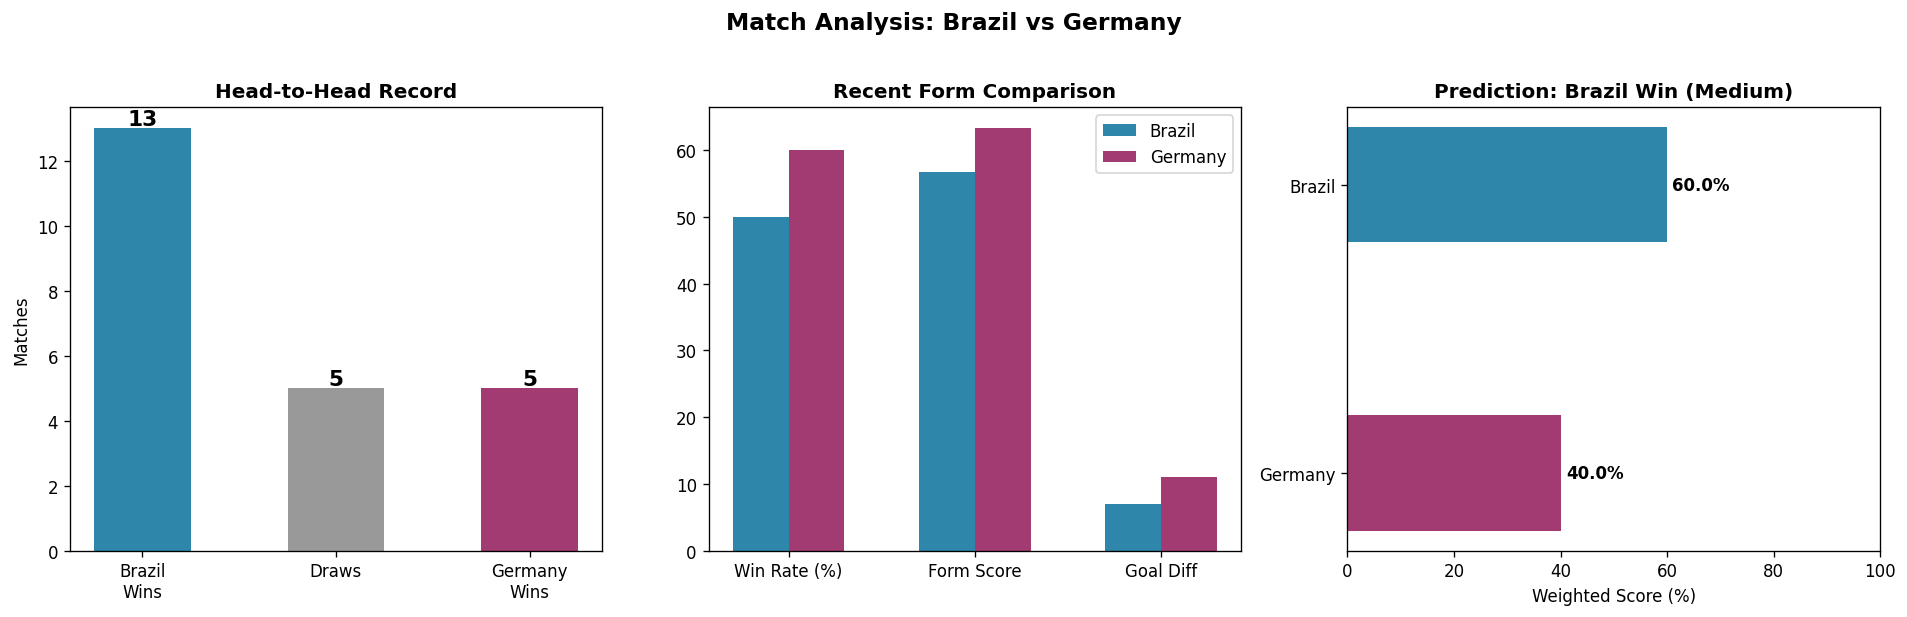


Prediction Factors:


,Factor,Brazil,Germany,Advantage
0,Recent Form Score,56.700000,63.300000,Germany
1,Head-to-Head Wins,13.000000,5.000000,Brazil
2,Overall WC Win Rate,66.700000,60.700000,Brazil
3,H2H Goal Average,1.780000,1.350000,Brazil
4,Recent Goal Diff,7.000000,11.000000,Germany



Step 2: Generating LLM analysis...

**MATCH PREVIEW**

The upcoming clash between Brazil and Germany promises to be a thrilling encounter, steeped in history and competitive spirit. Both teams are giants in the world of football, with a rich legacy of success on the international stage. Brazil, known for their flair and attacking prowess, will face off against Germany, a team renowned for their tactical discipline and resilience. This match is not just a contest of skill but also a battle of strategies, as both teams aim to assert their dominance.

**KEY STATISTICS**

- **Head-to-Head Record:** Brazil has a significant edge with 13 wins out of 23 encounters, while Germany has secured 5 victories, and 5 matches have ended in draws.
- **Goals Scored in Head-to-Head:** Brazil has scored 41 goals compared to Germany's 31, with Brazil averaging 1.78 goals per match and Germany 1.35.
- **Recent Form:** In their last 10 matches, Brazil has a win rate of 50.0% with a goal difference of +7, wh

In [ ]:
# -------------------------------------------------------------------
# Full prediction pipeline demonstration
# -------------------------------------------------------------------

def run_prediction_pipeline(team_a: str, team_b: str):
    """Execute the full prediction pipeline with visualization and LLM synthesis."""
    print(f"{'='*70}")
    print(f"  MATCH PREDICTION: {team_a} vs {team_b}")
    print(f"{'='*70}\n")

    # Step 1: Compute features and visualize
    print("Step 1: Computing features and generating visualizations...\n")
    features = visualize_prediction(team_a, team_b)

    if features.get("errors"):
        return

    # Step 2: LLM Synthesis
    print(f"\n{'='*70}")
    print("Step 2: Generating LLM analysis...\n")
    report = report_output_fn(f"{team_a} vs {team_b}")
    print(report)

    print(f"\n{'='*70}")
    print("Pipeline complete.")
    return features


# Run a demonstration prediction
features_demo = run_prediction_pipeline("Brazil", "Germany")


## 17. End-to-End Demo Examples

### Demo A: Conversational Q&A

We demonstrate the RAG chatbot answering various World Cup questions.


In [ ]:
# Demo: Set user preferences first
print("Setting user preferences...\n")
print(_handle_preference("set:favorite_team:Brazil"))
print(_handle_preference("set:answer_style:detailed"))
print(f"\nCurrent preferences:\n{get_user_preferences()}")


Setting user preferences...

Preference updated: favorite_team = Brazil
Preference updated: answer_style = detailed

Current preferences:
{
  "favorite_team": "Brazil",
  "answer_style": "detailed",
  "comparison_team": "Not set",
  "prediction_format": "full"
}


In [ ]:
# Demo Query 1: Which teams have won the most World Cups?
print("=" * 70)
print("QUERY 1: Which teams have won the most World Cups?")
print("=" * 70)
response = agent_executor.invoke({"input": "Which teams have won the most World Cups?"})
print("\nFINAL ANSWER:")
print(response["output"])


QUERY 1: Which teams have won the most World Cups?


> Entering new AgentExecutor chain...
To answer the question about which teams have won the most World Cups, I should retrieve historical World Cup data regarding the number of titles won by each team. This will provide a clear overview of the most successful teams in World Cup history.

Action: retrieval_tool
Action Input: "teams with the most World Cup wins"[Source 1: team_summary]
United States has played 37 World Cup matches across 11 tournaments (1930, 1934, 1950, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2022). Record: 9 wins, 8 draws, 20 losses. Goals scored: 40. Goals conceded: 66. GD: -26. Win rate: 24.3%.

[Source 2: team_summary]
Germany has played 112 World Cup matches across 20 tournaments (1934, 1938, 1954, 1958, 1962, 1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022). Record: 68 wins, 21 draws, 23 losses. Goals scored: 232. Goals conceded: 130. GD: 102. Win rate: 60.7%.

[Source 

In [ ]:
# Demo Query 2: Brazil historical performance
print("=" * 70)
print("QUERY 2: What is Brazil's historical World Cup performance?")
print("=" * 70)
response = agent_executor.invoke({"input": "What is Brazil's historical World Cup performance?"})
print("\nFINAL ANSWER:")
print(response["output"])


QUERY 2: What is Brazil's historical World Cup performance?


> Entering new AgentExecutor chain...
To provide a detailed overview of Brazil's historical World Cup performance, I should retrieve relevant historical data about Brazil's participation in the World Cup tournaments. This will include their wins, overall performance, and notable achievements.

Action: llm_answer_synthesis_tool
Action Input: "Brazil's historical World Cup performance"Brazil has a storied history in the FIFA World Cup, having participated in 22 tournaments from 1930 to 2022. Over these tournaments, Brazil has played a total of 114 matches, achieving 76 wins, 19 draws, and 19 losses. This impressive record gives Brazil a win rate of 66.7%. Throughout these matches, Brazil has scored 237 goals and conceded 108, resulting in a goal difference of 129.

In terms of head-to-head World Cup records against specific teams, Brazil has faced Uruguay twice, with each team winning one match and no draws. The goal tally in 

In [ ]:
# Demo Query 3: Compare two teams
print("=" * 70)
print("QUERY 3: Compare Argentina and France in World Cup history")
print("=" * 70)
response = agent_executor.invoke({"input": "Compare Argentina and France in World Cup history"})
print("\nFINAL ANSWER:")
print(response["output"])


QUERY 3: Compare Argentina and France in World Cup history


> Entering new AgentExecutor chain...
To compare Argentina and France in World Cup history, I will retrieve relevant historical data about both teams, including their performances, achievements, and head-to-head records in the World Cup. 

Action: retrieval_tool
Action Input: "Argentina vs France World Cup history comparison"[Source 1: head_to_head]
Head-to-head World Cup record: Argentina vs France: 4 matches. Argentina wins: 2, France wins: 1, Draws: 1. Goals: Argentina 9, France 8.

[Source 2: head_to_head]
Head-to-head World Cup record: Austria vs France: 2 matches. Austria wins: 1, France wins: 1, Draws: 0. Goals: Austria 3, France 3.

[Source 3: head_to_head]
Head-to-head World Cup record: France vs Paraguay: 2 matches. France wins: 2, Paraguay wins: 0, Draws: 0. Goals: France 8, Paraguay 3.

[Source 4: head_to_head]
Head-to-head World Cup record: Argentina vs Switzerland: 2 matches. Argentina wins: 2, Switzerland wins:

### Demo B: Match Prediction Flow

  MATCH PREDICTION: Argentina vs France

Step 1: Computing features and generating visualizations...



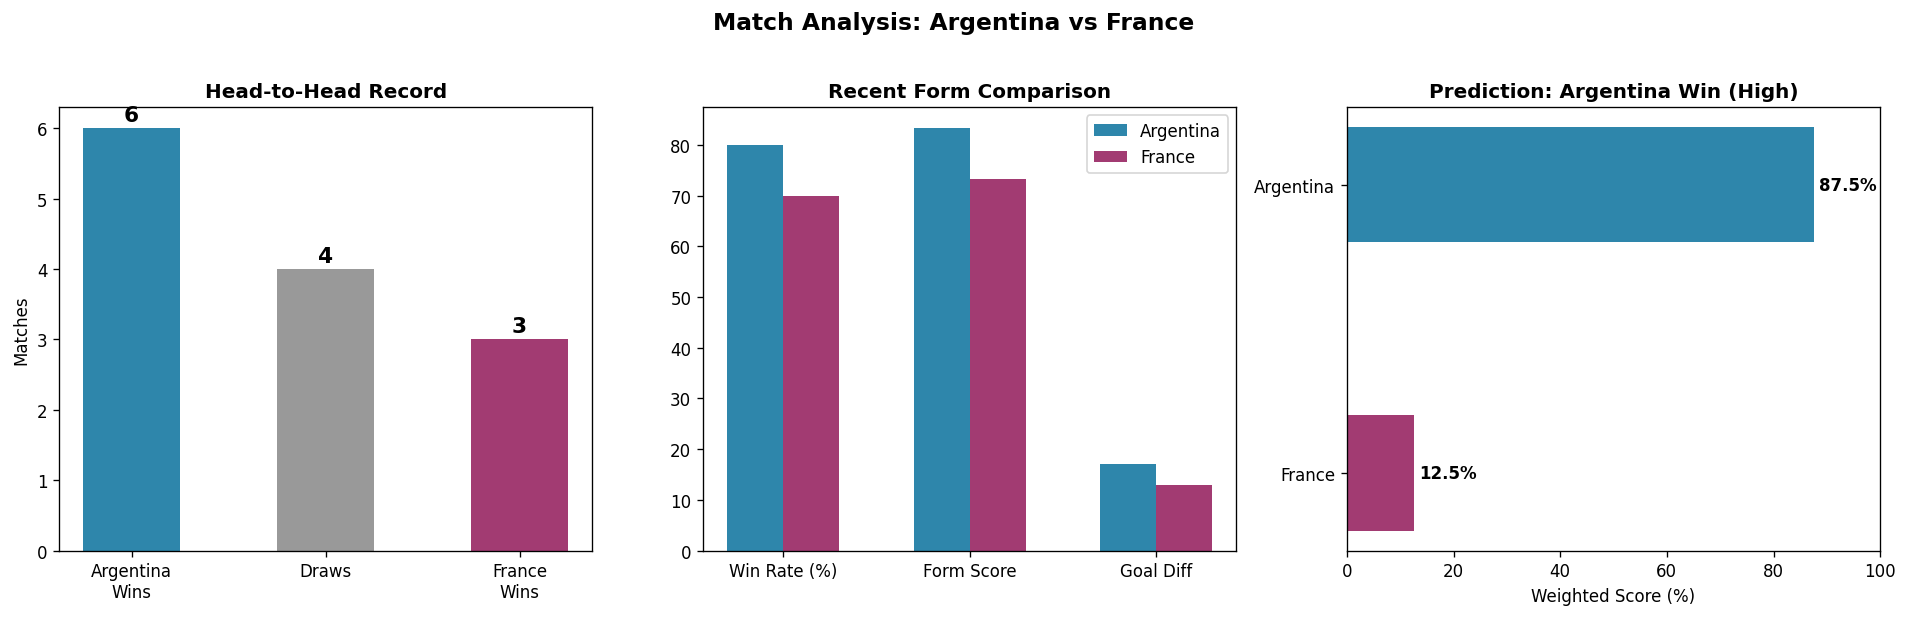


Prediction Factors:


,Factor,Argentina,France,Advantage
0,Recent Form Score,83.300000,73.300000,Argentina
1,Head-to-Head Wins,6.000000,3.000000,Argentina
2,Overall WC Win Rate,53.400000,53.400000,Even
3,H2H Goal Average,1.380000,1.080000,Argentina
4,Recent Goal Diff,17.000000,13.000000,Argentina



Step 2: Generating LLM analysis...

**MATCH PREVIEW**

As Argentina and France prepare to face off, the stage is set for a thrilling encounter between two footballing powerhouses. Both teams have a rich history in international football, and their head-to-head record reflects a competitive rivalry. Argentina, with a slight edge in past meetings, will look to capitalize on their recent form and historical success against France. Meanwhile, France will aim to leverage their attacking prowess to turn the tide in their favor. This match promises to be a captivating contest, with both sides eager to assert their dominance on the world stage.

**KEY STATISTICS**

- **Head-to-Head Record**: Argentina leads with 6 wins, while France has 3 victories, and there have been 4 draws in their 13 encounters.
- **Goals Scored in Head-to-Head**: Argentina has scored 18 goals (1.38 average per match), while France has netted 14 goals (1.08 average per match).
- **Recent Form**: Argentina boasts an impre

In [ ]:
# Demo Prediction 1: Argentina vs France
features_arg_fra = run_prediction_pipeline("Argentina", "France")


  MATCH PREDICTION: Spain vs Netherlands

Step 1: Computing features and generating visualizations...



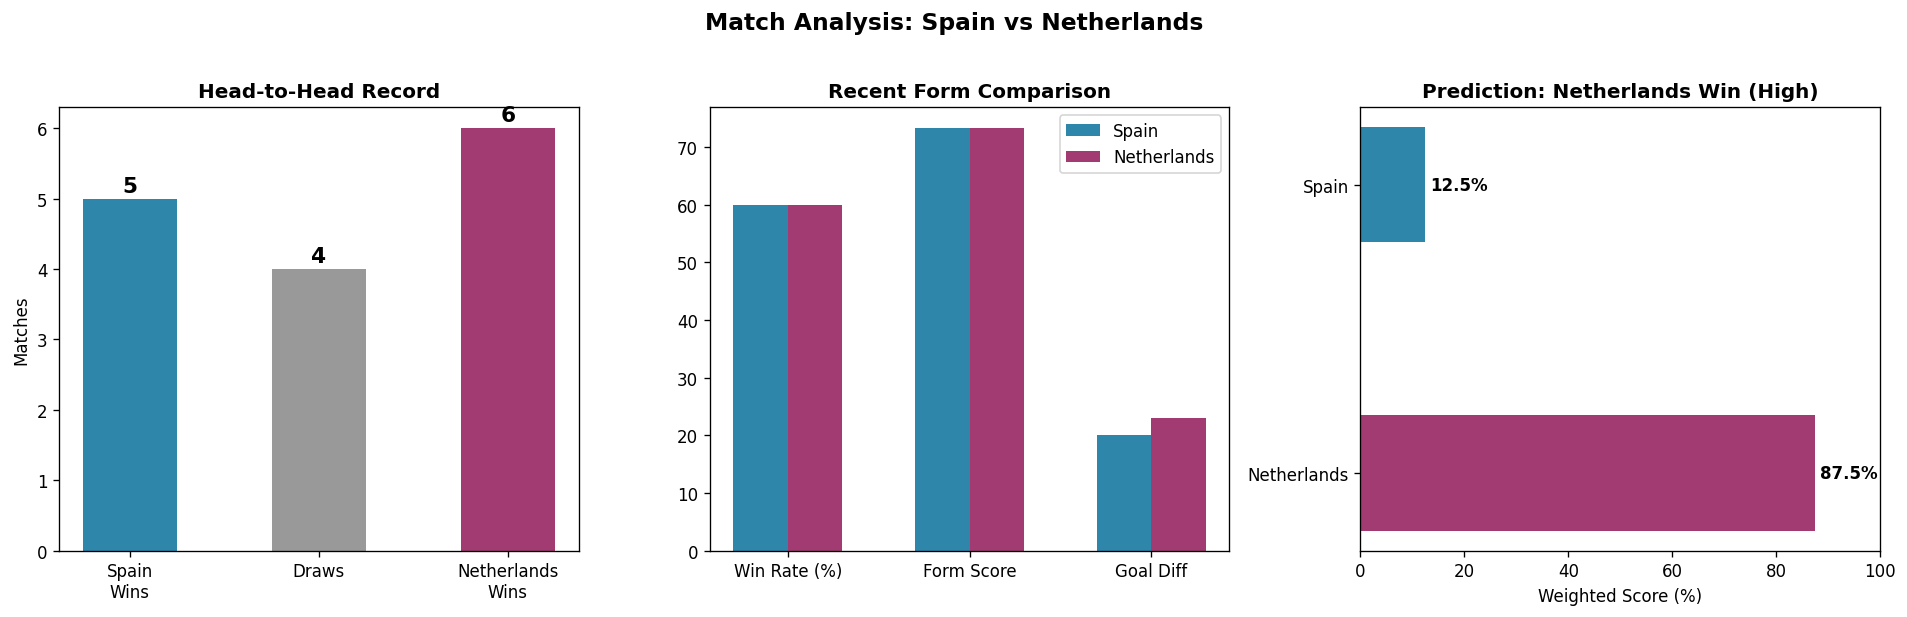


Prediction Factors:


,Factor,Spain,Netherlands,Advantage
0,Recent Form Score,73.300000,73.300000,Even
1,Head-to-Head Wins,5.000000,6.000000,Netherlands
2,Overall WC Win Rate,46.300000,54.500000,Netherlands
3,H2H Goal Average,1.530000,1.600000,Netherlands
4,Recent Goal Diff,20.000000,23.000000,Netherlands



Step 2: Generating LLM analysis...

### MATCH PREVIEW

As Spain prepares to face the Netherlands, fans can anticipate a thrilling encounter between two European powerhouses. Historically, these teams have been closely matched, with the Netherlands holding a slight edge in head-to-head victories. Both teams come into this match with strong recent form, making this a highly anticipated clash in the tournament.

### KEY STATISTICS

- **Head-to-Head Record**: Out of 15 encounters, the Netherlands has won 6 times, while Spain has secured 5 victories, with 4 matches ending in a draw.
- **Recent Form**: Both teams have an identical recent form score of 73.3, with each winning 6 and drawing 4 of their last 10 matches.
- **Goal Statistics**: Spain has scored 33 goals and conceded 13 in their last 10 matches, while the Netherlands has scored 32 and conceded 9.
- **Overall Win Rate**: Spain has a win rate of 46.3% across 67 matches, whereas the Netherlands boasts a higher win rate of 54.5% from 

In [ ]:
# Demo Prediction 2: Spain vs Netherlands
features_spa_ned = run_prediction_pipeline("Spain", "Netherlands")


## 18. Evaluation and Test Queries

We run a battery of test queries to verify the system handles various scenarios correctly.


In [ ]:
# Test queries covering different scenarios
test_queries = [
    "Who won the 2010 World Cup?",
    "How many World Cup titles does Italy have?",
    "What was the highest-scoring World Cup final?",
    "Tell me about the 1950 World Cup",
    "Which country has hosted the most World Cups?",
]

for i, query in enumerate(test_queries, 1):
    print(f"\n{'='*60}")
    print(f"TEST {i}: {query}")
    print("=" * 60)
    try:
        response = agent_executor.invoke({"input": query})
        print(f"Answer: {response['output'][:500]}")
    except Exception as e:
        print(f"Error: {e}")



TEST 1: Who won the 2010 World Cup?


> Entering new AgentExecutor chain...
To answer the question about the winner of the 2010 World Cup, I should retrieve historical World Cup data. 

Action: retrieval_tool
Action Input: "2010 World Cup winner"[Source 1: tournament_summary]
The 2010 FIFA World Cup was held in South Africa. The winner was Spain, defeating Netherlands in the final. A total of 145 goals were scored in 64 matches. 32 teams participated.

[Source 2: tournament_summary]
The 1990 FIFA World Cup was held in Italy. The winner was Germany, defeating Argentina in the final. A total of 115 goals were scored in 52 matches. 24 teams participated.

[Source 3: goalscorer]
Thomas Müller scored 10 goals in FIFA World Cup matches, playing for Germany.

[Source 4: tournament_summary]
The 2006 FIFA World Cup was held in Germany. The winner was Italy, defeating France in the final. A total of 147 goals were scored in 64 matches. 32 teams participated.

[Source 5: tournament_summary]
The 

In [ ]:
# Test preference-aware responses
print("Setting preference to brief style...")
set_user_preference("answer_style", "brief")

response = agent_executor.invoke({"input": "Give me a quick summary of Germany in World Cups"})
print("\nBrief-style answer:")
print(response["output"])

# Reset to detailed
set_user_preference("answer_style", "detailed")


Setting preference to brief style...


> Entering new AgentExecutor chain...
To provide a quick summary of Germany's performance in World Cups, I will use the llm_answer_synthesis_tool to gather relevant historical data about Germany's participation and achievements in the tournament.

Action: llm_answer_synthesis_tool
Action Input: Quick summary of Germany's performance in World CupsGermany has played 112 World Cup matches across 20 tournaments, achieving 68 wins, 21 draws, and 23 losses. They have scored 232 goals and conceded 130, with a goal difference of 102 and a win rate of 60.7%. Notably, Germany has a strong head-to-head record against teams like Uruguay and Mexico but has an even record against Hungary. Keep in mind that these statistics do not include the performance of the German DR, which played in the 1974 World Cup.I now know the final answer.

Final Answer: Germany has participated in 20 World Cup tournaments, playing 112 matches with 68 wins, 21 draws, and 23 losses. T

'Preference updated: answer_style = detailed'

In [ ]:
# Test edge case: Unknown team
print("\nTesting unknown team prediction:")
result = match_prediction_feature_fn("Atlantis vs Brazil")
print(result[:300])



Testing unknown team prediction:
Error: Team 'Atlantis' not found. Available include: Abkhazia, Afghanistan, Albania, Alderney, Algeria, Ambazonia, American Samoa, Andalusia, Andorra, Angola, Anguilla, Antigua and Barbuda, Arameans Suryoye, Argentina, Armenia, Artsakh, Aruba, Asturias, Australia, Austria...


### Demo C: Interactive Query Mode

Run the cell below to enter your own questions interactively. Type `quit` to stop.
Prefix with `predict:` to run a match prediction (e.g., `predict: Argentina vs France`).

World Cup Analyst Chatbot -- Interactive Mode
Type your question, or 'predict: Team A vs Team B' for match prediction.
Type 'quit' to exit.

[1/3] Your question: predict: Argentina vs France
  MATCH PREDICTION: Argentina vs France

Step 1: Computing features and generating visualizations...



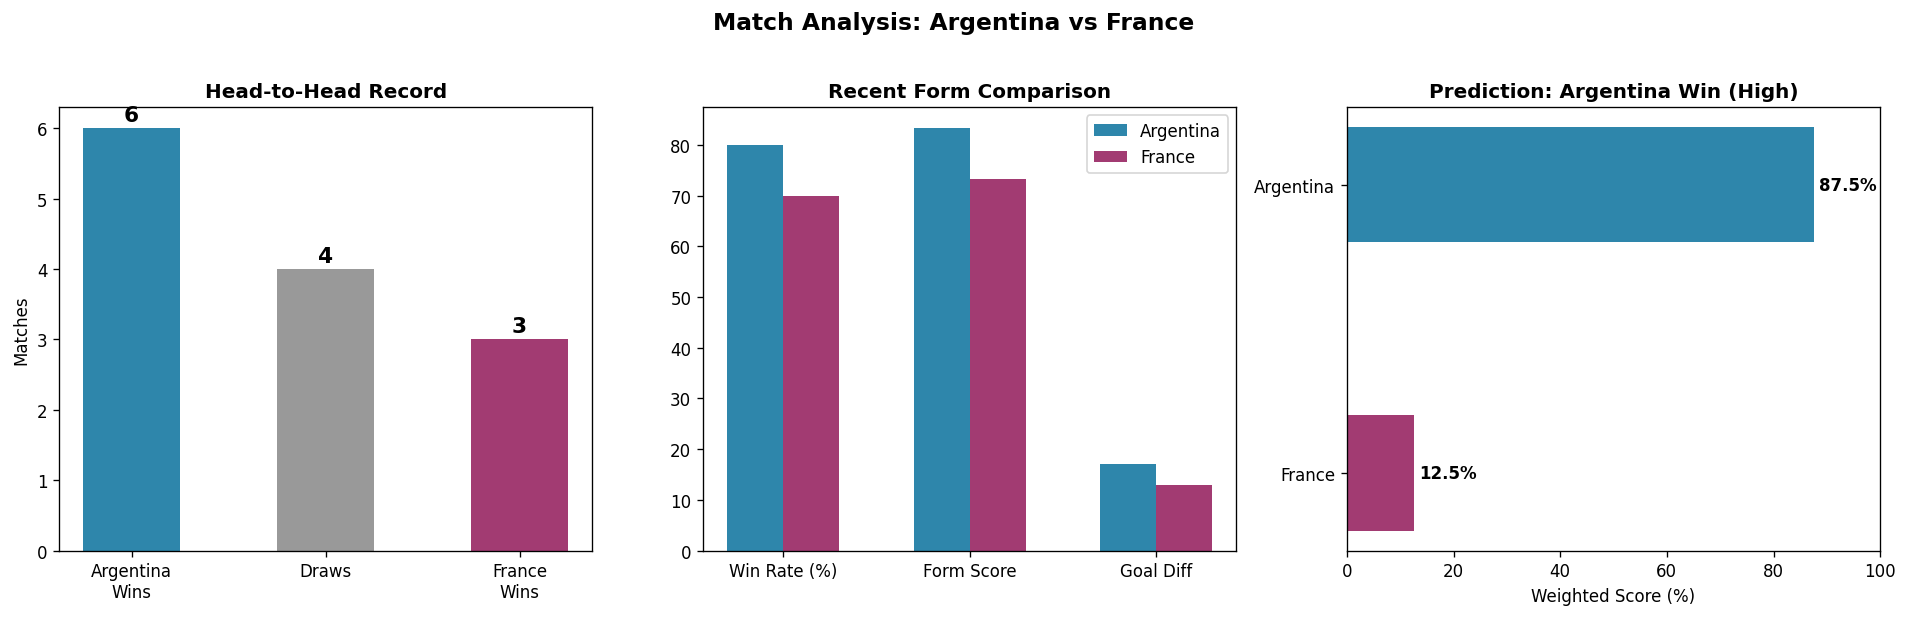


Prediction Factors:


,Factor,Argentina,France,Advantage
0,Recent Form Score,83.300000,73.300000,Argentina
1,Head-to-Head Wins,6.000000,3.000000,Argentina
2,Overall WC Win Rate,53.400000,53.400000,Even
3,H2H Goal Average,1.380000,1.080000,Argentina
4,Recent Goal Diff,17.000000,13.000000,Argentina



Step 2: Generating LLM analysis...

**MATCH PREVIEW**

As the world turns its eyes to this highly anticipated clash, Argentina and France prepare to face off in what promises to be a thrilling encounter. Both teams have a rich history in international football, and their previous meetings have often been closely contested. With Argentina's recent form and historical edge in head-to-head matchups, they enter this match with a slight advantage. However, France's ability to perform on the big stage cannot be underestimated, making this a must-watch for football enthusiasts, including fans of Brazil who may be keen to see how these two powerhouses stack up against their own team.

**KEY STATISTICS**

- **Head-to-Head Record:** Argentina leads with 6 wins, while France has secured 3 victories. There have been 4 draws in their 13 encounters.
- **Goals Scored in Head-to-Head Matches:** Argentina has scored 18 goals, averaging 1.38 goals per match, compared to France's 14 goals and 1.08 avera

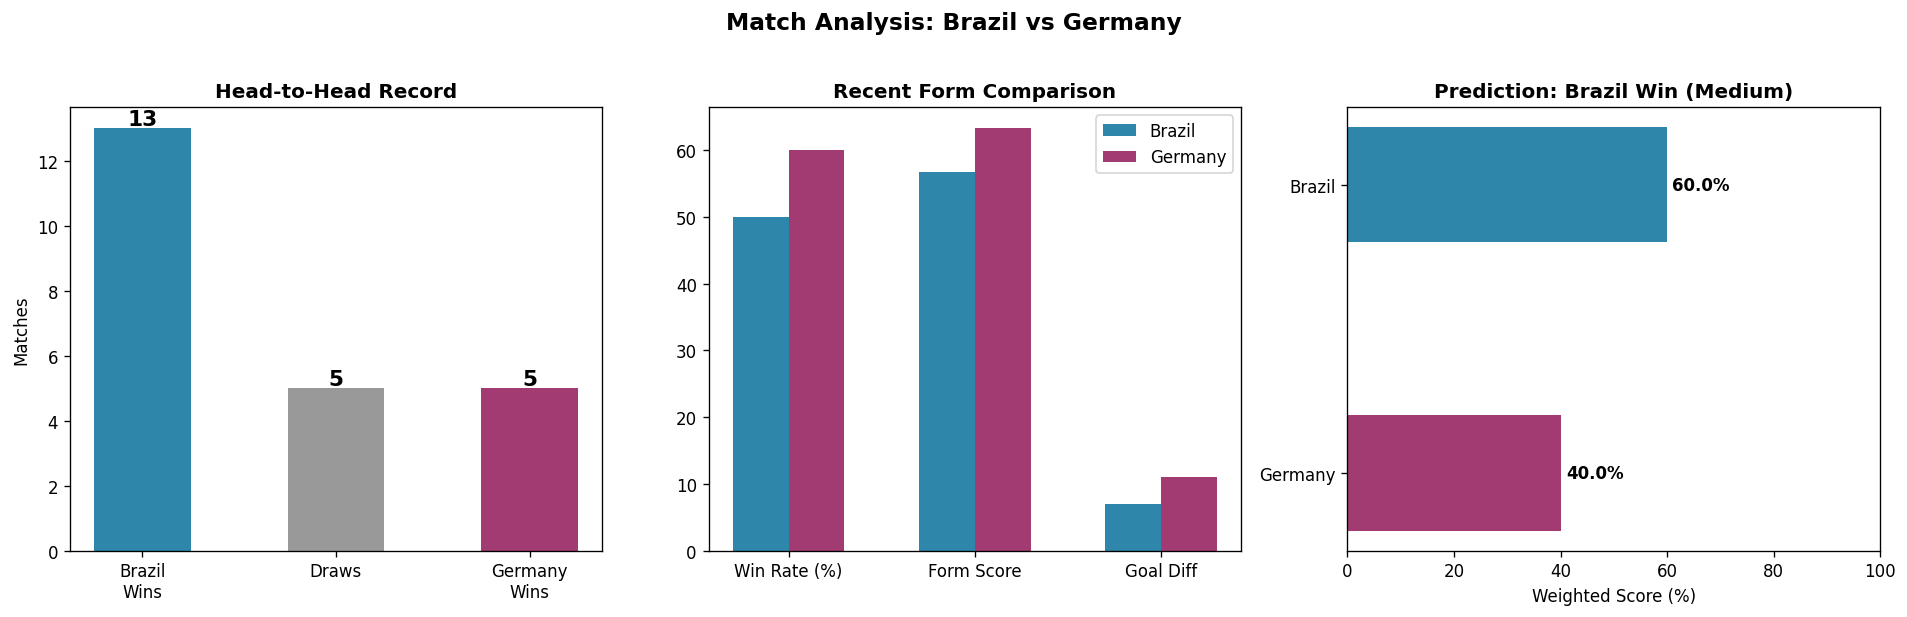


Prediction Factors:


,Factor,Brazil,Germany,Advantage
0,Recent Form Score,56.700000,63.300000,Germany
1,Head-to-Head Wins,13.000000,5.000000,Brazil
2,Overall WC Win Rate,66.700000,60.700000,Brazil
3,H2H Goal Average,1.780000,1.350000,Brazil
4,Recent Goal Diff,7.000000,11.000000,Germany



Step 2: Generating LLM analysis...

### MATCH PREVIEW

The upcoming clash between Brazil and Germany promises to be a thrilling encounter, steeped in history and competitive spirit. Both teams have a storied rivalry, with Brazil holding a significant edge in their head-to-head record. This match will see Brazil, a team with a rich World Cup legacy, face off against Germany, known for their tactical prowess and resilience. Fans of Brazil, in particular, will be eager to see their team continue their dominance in this fixture.

### KEY STATISTICS

- **Head-to-Head Record**: Brazil leads with 13 wins out of 23 matches, while Germany has secured 5 victories, and 5 matches have ended in draws.
- **Goals Scored**: Brazil has scored 41 goals against Germany's 31 in their encounters, with Brazil averaging 1.78 goals per match compared to Germany's 1.35.
- **Recent Form**: Over the last 10 matches, Brazil has a win rate of 50.0% with a form score of 56.7, while Germany has a slightly better wi

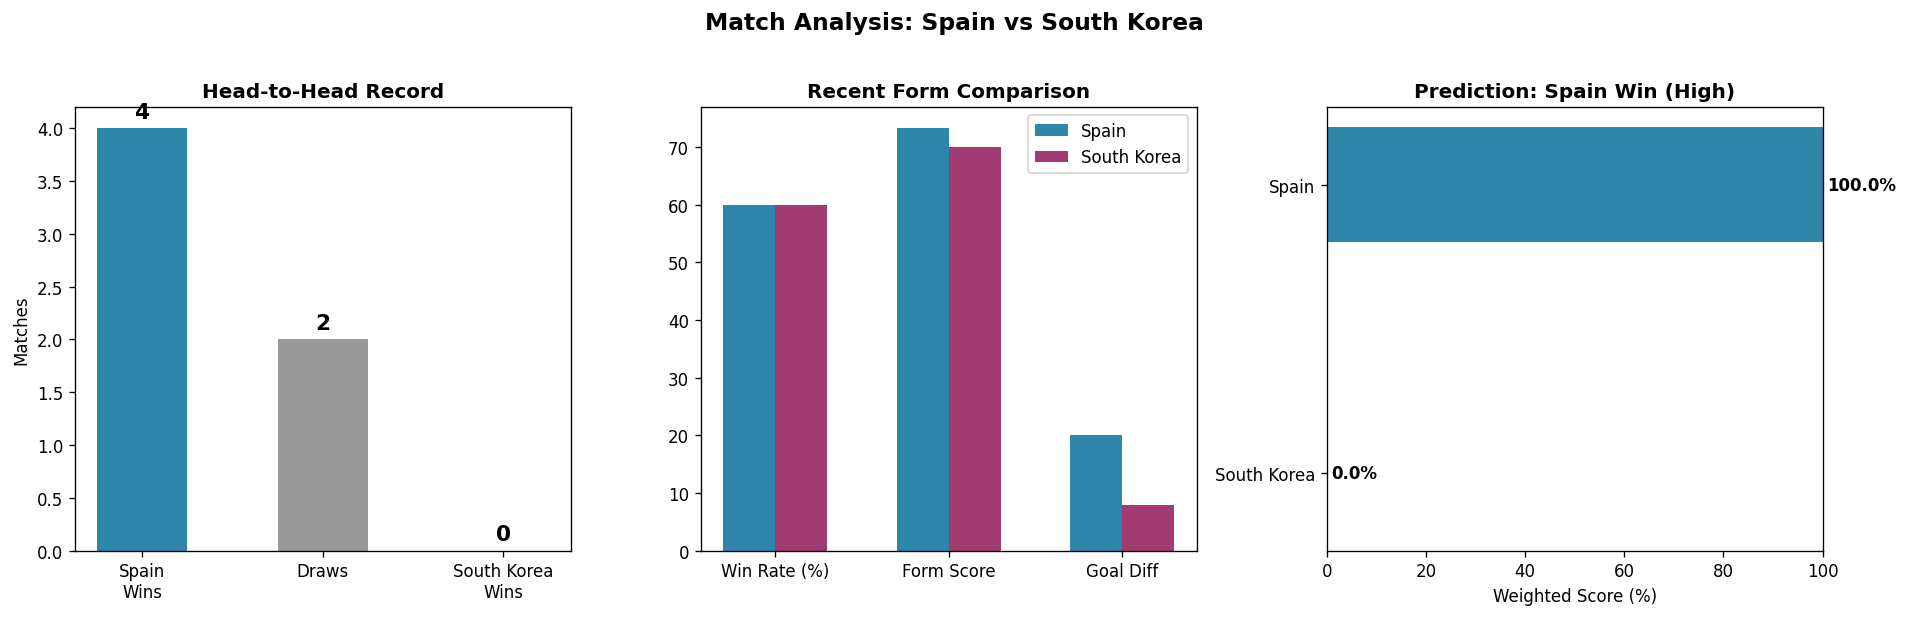


Prediction Factors:


,Factor,Spain,South Korea,Advantage
0,Recent Form Score,73.300000,70.000000,Spain
1,Head-to-Head Wins,4.000000,0.000000,Spain
2,Overall WC Win Rate,46.300000,18.400000,Spain
3,H2H Goal Average,2.670000,0.830000,Spain
4,Recent Goal Diff,20.000000,8.000000,Spain



Step 2: Generating LLM analysis...

**MATCH PREVIEW**

As Spain prepares to face South Korea, the historical and statistical data heavily favor the European side. Spain, known for its technical prowess and tactical discipline, will look to extend its dominance over South Korea, a team that has yet to secure a victory against them in their six previous encounters. South Korea, however, will aim to leverage its recent form and resilience to challenge Spain's supremacy.

**KEY STATISTICS**

- **Head-to-Head Record**: Spain leads with 4 wins, while South Korea has yet to win, and there have been 2 draws.
- **Goals Scored in Head-to-Head**: Spain has scored 16 goals (average 2.67 per match), while South Korea has managed 5 goals (average 0.83 per match).
- **Recent Form**: Both teams have a win rate of 60% over their last 10 matches, but Spain boasts a higher goal difference of 20 compared to South Korea's 8.
- **Overall World Cup Win Rate**: Spain has a win rate of 46.3% in World Cup hist

In [ ]:
# -------------------------------------------------------------------
# Interactive query mode for live demo
# -------------------------------------------------------------------

def interactive_session(max_turns=3):
    """Run an interactive Q&A session. Set max_turns to limit API calls during testing."""
    print("World Cup Analyst Chatbot -- Interactive Mode")
    print("Type your question, or 'predict: Team A vs Team B' for match prediction.")
    print("Type 'quit' to exit.\n")

    for turn in range(max_turns):
        try:
            query = input(f"[{turn+1}/{max_turns}] Your question: ")
        except EOFError:
            break

        if not query or query.strip().lower() == "quit":
            break

        if query.strip().lower().startswith("predict:"):
            teams_str = query.split(":", 1)[1].strip()
            parts = [t.strip() for t in teams_str.split(" vs ")]
            if len(parts) == 2:
                run_prediction_pipeline(parts[0], parts[1])
            else:
                print("Format: predict: Team A vs Team B")
        else:
            try:
                response = agent_executor.invoke({"input": query})
                print(f"\nAnswer: {response['output']}\n")
            except Exception as e:
                print(f"Error: {e}\n")

    print("Session ended.")


# Uncomment the line below to start an interactive session during presentation:
interactive_session(max_turns=3)
print("Interactive session function defined. Uncomment the call above to use during demo.")


### Gradio Web Interface

Run the cell below to launch an interactive chatbot with a shareable public URL.
Use it for live demo during the presentation.

In [ ]:
import gradio as gr

def chat(message, history):
    try:
        msg = message.strip()
        if msg.lower().startswith("predict"):
            teams_str = msg.split(":", 1)[1].strip() if ":" in msg else msg[7:].strip()
            parts = [t.strip() for t in teams_str.split(" vs ")]
            if len(parts) == 2:
                return report_output_fn(f"{parts[0]} vs {parts[1]}")
            return "Format: predict: Team A vs Team B"
        return agent_executor.invoke({"input": message})["output"]
    except Exception as e:
        return f"Error: {str(e)}"

demo = gr.ChatInterface(
    fn=chat,
    title="FIFA World Cup AI Analyst (1872-2026)",
    description="Ask about World Cup history, team stats, and match predictions. Try: predict: Brazil vs France",
    examples=[
        "Which teams have won the most World Cups?",
        "What is Brazil's historical World Cup performance?",
        "Compare Argentina and Germany in World Cup history",
        "predict: Brazil vs France",
        "predict: Spain vs Netherlands",
    ],
    theme="soft"
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c2ebdb33dd28e7f7c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 19. Limitations and Responsible AI

### Disclaimer
This project is an **educational exercise** developed for a university hackathon.
It is **not** professional sports analytics or betting advice.

### Known Limitations
1. **Data coverage**: The dataset covers international matches through early 2026 including all World Cups through 2022. As with any historical dataset, the most recent matches may not yet be reflected.
2. **Recent form scope**: Recent form is computed from the last 10 international matches across all competitions, which provides a broad signal but may weigh friendlies equally with competitive fixtures.
3. **Historical comparisons**: Comparing teams across different football eras naturally involves some approximation, as rules, team composition, and competition standards evolve over time.
4. **Prediction scope**: Predictions are based on historical statistical patterns and do not incorporate real-time factors such as current squad fitness, managerial tactics, or match-day conditions.
5. **Model behavior**: The LLM synthesizes text based on retrieved and computed evidence, and is explicitly prompted to avoid speculation, though no language model is perfectly constrained.

### Responsible AI Practices
- All statistics are computed from verifiable, publicly available source data
- The LLM is instructed to avoid hallucinating statistics in all 4 prompt templates
- Confidence levels and limitations are stated with every prediction
- A dedicated fallback prompt prevents guessing when evidence is insufficient
- Prompts explicitly discourage use as betting advice
- Data sources are cited with URLs and licensing information

## 20. Conclusion

This notebook implements a complete **World Cup Match Predictor and Analyst Chatbot** using
a LangChain-powered two-phase pipeline:

**Phase 1 -- Data Pipeline (6 sequential functions):**
`dataset_discovery` -> `data_ingestion` -> `data_validation` -> `preprocessing` -> `eda_visualization` -> `vector_store_builder`

These run once at notebook startup to prepare clean data, generate visualizations, and build
the FAISS vector store.

**Phase 2 -- Interactive Agent (5 LangChain Tools):**

| Tool | Responsibility |
|------|---------------|
| `retrieval_tool` | Similarity search over vector store |
| `llm_answer_synthesis_tool` | RAG-based Q&A with grounded prompts and fallback handling |
| `match_prediction_feature_tool` | Compute 5 weighted prediction factors from data |
| `report_or_output_tool` | Full match prediction report with LLM synthesis |
| `user_preference_tool` | Persistent user preferences (favorite team, answer style) |

**Key strengths:**
- Dataset covers 49,000+ international matches (1872-2026) including all World Cups through 2022
- Recent form uses all competitions (friendlies, qualifiers, tournaments) for richer prediction signals
- Team names normalized via former_names.csv (36 historical mappings) for cross-era consistency
- RAG pipeline with FAISS vector store and OpenAI embeddings over 200+ curated documents (including top scorers)
- Evidence-based prediction using 5 weighted statistical factors -- all numbers computed from code, never LLM-generated
- 11 presentation-ready visualizations spanning tournament trends, team performance, and goal scoring analysis
- Conversation memory via custom ReAct prompt with `{chat_history}` and persistent user preferences
- Dedicated fallback prompt for queries outside data coverage
- Gradio web interface for interactive live demo
- Responsible AI practices with grounding, limitations, and educational disclaimers

### Architecture Summary
```
Phase 1 (Batch):
  CSV Files -> Validation -> Preprocessing -> EDA -> Document Builder -> FAISS Vector Store

Phase 2 (Interactive):
  User Query -> ReAct Agent (with chat_history) -> [Tool Selection]
                                                        |
                  +---------+-----------+----------+----+
                  |         |           |          |
            retrieval  prediction  report   preferences
                  |         |           |
            RAG Synth  Features    LLM Preview
                  |         |           |
                  +----+----+-----------+
                       |
                Grounded Response (with limitations)
```

## 21. Appendix

### Team Contributions

| Member | Contributions |
|--------|--------------|
| Novia Dsilva | LangChain ReAct agent architecture and tool orchestration, RAG retrieval pipeline design, prediction feature engineering with weighted factor computation |
| Sushmitha Sudharsan | Data ingestion, preprocessing, and validation pipeline, FAISS vector store construction, prompt template development for RAG and prediction synthesis, state persistence |
| Tanmayi Shurpali | LLM-grounded prediction synthesis chain, EDA visualizations, evaluation and response quality testing, Gradio interactive interface, responsible AI compliance and project documentation |

This project was developed collaboratively with shared contribution across all core GenAI components, including LangChain architecture, prompt engineering, retrieval-augmented generation, prediction reasoning, and output grounding. The responsibilities listed above reflect each member's primary area of ownership within the shared development process.

### Future Improvements

1. **Elo rating system** -- Dynamic Elo model for more sophisticated predictions
2. **Player-level factors** -- Use squad quality metrics from goalscorer data
3. **StatsBomb event data** -- Passes, shots, pressure for deeper analysis
4. **Ensemble prediction** -- Combine statistical, ML, and heuristic methods
5. **Tournament bracket simulation** -- Simulate entire tournament outcomes
6. **Stage-aware analysis** -- Integrate dataset with match stages (group, knockout, final)
7. **Live API integration** -- Connect to API-Football for real-time data